# **Confusion Matrix Comparison**
---
Edit: 21/05/2026

## **Section 0: Import important library**

In [1]:
import os
import itertools
import time
from psutil import virtual_memory

import pandas as pd
import numpy as np
import random as rd

import tensorflow as tf
import keras
os.environ["KERAS_BACKEND"] = "tensorflow"
import sklearn
import joblib

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.font_manager as fm
import seaborn as sns
import cv2
import albumentations as A
import matplotlib.image as mpimg

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

### **Setting a seed system environment and path**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def set_seed(seed):
    """
        ใช้สำหรับการตั้งค่า Seed Environment เพื่อให้ผลลัพธ์สามารถ Reproduce ได้
        Arg:
            seed คือ ค่า Integer สำหรับกำหนด Seed
    """
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()
    keras.utils.set_random_seed(seed)

    np.random.seed(seed)
    rd.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

    print(f"The seed number has been set at {seed}")

SEED = 42
set_seed(SEED)

DRIVE_DIR = "/content/drive/MyDrive/CP461/mainProject" # Drive Directory
ASSETS_PATH = f"{DRIVE_DIR}/assets" # Assets Path
INDEX_SETTING = f"{DRIVE_DIR}/datasets/indexSetting"

# Setting font
fm.fontManager.addfont(f"{ASSETS_PATH}/fonts/OPTITimes-Roman.otf")
font_prop = fm.FontProperties(fname=f"{ASSETS_PATH}/fonts/OPTITimes-Roman.otf")
font_name = font_prop.get_name()
plt.rcParams["font.family"] = font_name

MODEL_CODE_NAME = "EfficientNetV2B0"

MODEL_PATH = f"{DRIVE_DIR}/models" # <= สำหรับเก็บ Log Model ต่าง ๆ
OPTIMIZER_NAME = "SGD" # <= Optimizer อะไร
TYPE = "FineTuning" # <= FineTuning หรือ FeatureExtraction
ROUND_NUM = 1 # <= รันครั้งที่เท่าไหร่

# MLP
MLP_MODEL_NAME = "EfficientNetV2B0WithMLP"
MLP_MODEL_FULL_PATH = f"{MODEL_PATH}/{MLP_MODEL_NAME}_{TYPE}_{OPTIMIZER_NAME}_{ROUND_NUM}"
ASSETS_FOR_MLP_MODEL_PATH = f"{MLP_MODEL_FULL_PATH}/assets"

# Baseline
MODEL_NAME = "EfficientNetV2B0PureCNN"
MODEL_FULL_PATH = f"{MODEL_PATH}/{MODEL_NAME}_{TYPE}_{OPTIMIZER_NAME}_{ROUND_NUM}"
ASSETS_FOR_MODEL_PATH = f"{MODEL_FULL_PATH}/assets"

MLP_MODEL_CHECKPOINT_PATH = f"{MLP_MODEL_FULL_PATH}/{MLP_MODEL_NAME}_best.keras"
MODEL_CHECKPOINT_PATH = f"{MODEL_FULL_PATH}/{MODEL_NAME}_best.keras"

The seed number has been set at 42


In [4]:
%%capture
!unzip /content/drive/MyDrive/CP461/mainProject/datasets/ham10000DatasetOversampling.zip -d /content/

In [5]:
DATASET_DIR = "/content/ham10000DatasetOversampling"

## **Section 1: Preprocessing images**

### **Load dataset**

In [6]:
class TFDatasetPipeline:
    def __init__(self,
                 transform=None,
                 rescale=None,
                 preprocess_input=None):
        """
        Args:
            transform (albumentations.Compose, optional):
                Pipeline ของ Albumentations สำหรับ Augmentation
            preprocess_input (function, optional):
                ฟังก์ชัน Preprocessing ของโมเดล (เช่น resnet.preprocess_input)
                หากต้องการแค่ Rescale ให้ส่ง: 1./255
        """
        self.transform = transform
        self.rescale = rescale
        self.preprocess_input = preprocess_input
        self.AUTOTUNE = tf.data.AUTOTUNE
        self.class_names = None

    def _build_class_names(self, df, y_cols, class_name_col, num_classes):
        if self.class_names is not None:
            return
        try:
            if class_name_col:
                mapping_df = df[[y_cols, class_name_col]].drop_duplicates().sort_values(by=y_cols)
                self.class_names = mapping_df[class_name_col].tolist()
                if len(self.class_names) != num_classes:
                    print(f"[Warning] Found {len(self.class_names)} class names but expected {num_classes}.")
            else:
                raise ValueError
        except Exception:
            print(f"[Warning] Could not extract class names. Using numeric labels instead.")
            self.class_names = [str(i) for i in range(num_classes)]

        print(f"Class indices: {dict(enumerate(self.class_names))}")

    def _transform_function(self, img_numpy):
        if self.transform is None:
            return img_numpy.astype(np.float32)

        img_uint8 = np.clip(img_numpy, 0, 255).astype(np.uint8)

        raw_img = {"image": img_uint8}
        transformed = self.transform(**raw_img)
        img_out = transformed["image"]

        if img_out.ndim == 2:
            img_out = np.stack([img_out] * 3, axis=-1)

        return img_out.astype(np.float32)

    @tf.function
    def _apply_transform(self, img_tensor, img_size):
        transformed = tf.numpy_function(
            func=self._transform_function,
            inp=[img_tensor],
            Tout=tf.float32
        )
        transformed.set_shape([*img_size, 3])
        return transformed

    def _load_and_resize(self, filepath, metadata, label, img_size):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        return img, metadata, label

    def _process_image(self, img, is_training, img_size):
        if is_training and self.transform:
            img = self._apply_transform(img, img_size)

        if self.preprocess_input:
            img = self.preprocess_input(img)
        elif self.rescale:
            img = img * self.rescale

        return img

    def _process_label(self, label, num_classes, class_mode):
        label = tf.cast(label, tf.int32)
        if class_mode == "categorical":
            label = tf.one_hot(label, num_classes)
        elif class_mode != "sparse":
            raise ValueError(f"Unknown class_mode: {class_mode}")
        return label

    def _finalize_data(self, img, metadata, label,
                       num_classes, img_size, is_training, class_mode,
                       meta_shape_num=0, meta_shape_cat=0):
        img = self._process_image(img, is_training, img_size)
        label = self._process_label(label, num_classes, class_mode)

        if meta_shape_num == 0 and meta_shape_cat == 0:
            return img, label
        else:
            m_num, m_cat = metadata
            m_num = tf.cast(m_num, tf.float32)
            m_cat = tf.cast(m_cat, tf.float32)
            if meta_shape_num > 0:
                m_num.set_shape([meta_shape_num])
            if meta_shape_cat > 0:
                m_cat.set_shape([meta_shape_cat])
            return ((img, m_num, m_cat), label)

    def flow_from_dataframe(
        self,
        df,
        X_cols,
        X_meta=None,
        y_cols=None,
        num_classes=None,
        class_name_col=None,
        target_size=(224, 224),
        batch_size=32,
        class_mode="categorical",
        is_training=False,
        seed=42
    ):

        self._build_class_names(df, y_cols, class_name_col, num_classes)
        num_files = len(df)
        print(f"Found {num_files} files belonging to {num_classes} classes.")

        meta_shape_num = 0
        meta_shape_cat = 0
        X_meta_num_data = [None] * num_files
        X_meta_cat_data = [None] * num_files

        if X_meta is not None:
            if X_meta[0] is not None:
                X_meta_num_data = X_meta[0].astype(np.float32)
                meta_shape_num = X_meta_num_data.shape[1]
            if X_meta[1] is not None:
                X_meta_cat_data = X_meta[1].astype(np.float32)
                meta_shape_cat = X_meta_cat_data.shape[1]
            print(f"[Info] Detected meta_shape_num={meta_shape_num}, meta_shape_cat={meta_shape_cat}")

        dataset = tf.data.Dataset.from_tensor_slices(
            (df[X_cols].values,
             X_meta_num_data if meta_shape_num > 0 else tf.zeros((num_files, 0), dtype=tf.float32),
             X_meta_cat_data if meta_shape_cat > 0 else tf.zeros((num_files, 0), dtype=tf.float32),
             df[y_cols].values)
        )

        dataset = dataset.map(
            lambda f, m_num, m_cat, l: self._load_and_resize(f, (m_num, m_cat), l, target_size),
            num_parallel_calls=self.AUTOTUNE
        )
        dataset = dataset.cache()

        if is_training:
            dataset = dataset.shuffle(buffer_size=num_files, seed=seed, reshuffle_each_iteration=True)

        dataset = dataset.map(
            lambda img, m, l: self._finalize_data(
                img, m, l, num_classes, target_size,
                is_training, class_mode,
                meta_shape_num=meta_shape_num,
                meta_shape_cat=meta_shape_cat
            ),
            num_parallel_calls=self.AUTOTUNE
        )

        dataset = dataset.batch(batch_size).prefetch(self.AUTOTUNE)
        return dataset

In [7]:
df_test = pd.read_csv(f"{INDEX_SETTING}/metadata_test.csv")
mlp_preprocessor = joblib.load(f"{INDEX_SETTING}/mlp_preprocess.joblib")
numeric_pipeline = mlp_preprocessor.named_transformers_["numeric"]
categorical_pipeline = mlp_preprocessor.named_transformers_["categorical"]

numeric_cols = [cols for name, trans, cols in mlp_preprocessor.transformers_ if name == "numeric"][0]
categorical_cols = [cols for name, trans, cols in mlp_preprocessor.transformers_ if name == "categorical"][0]

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

X_meta_num_test = df_test[numeric_cols]
X_meta_cat_test = df_test[categorical_cols]

# Build pipeline
x_meta_num_test = numeric_pipeline.transform(X_meta_num_test)
x_meta_cat_test = categorical_pipeline.transform(X_meta_cat_test).toarray()

X_meta_test = (x_meta_num_test, x_meta_cat_test)

print("Test meta data (Processed Shape)")
print(f"x_meta_num_test shape: {x_meta_num_test.shape}")
print(f"x_meta_cat_test shape: {x_meta_cat_test.shape}")

Numeric columns: ['age']
Categorical columns: ['sex', 'localization']
Test meta data (Processed Shape)
x_meta_num_test shape: (955, 1)
x_meta_cat_test shape: (955, 16)


In [8]:
def select_preprocess_input(model_name):
    if model_name == "EfficientNetV2B0":
        preprocess_input = keras.applications.efficientnet_v2.preprocess_input
        decode_predictions = keras.applications.efficientnet_v2.decode_predictions
    elif model_name == "MobileNetV3Large" or model_name == "MobileNetV3Small":
        preprocess_input = keras.applications.mobilenet_v3.preprocess_input
        decode_predictions = keras.applications.mobilenet_v3.decode_predictions
    elif model_name == "Xception":
        preprocess_input = keras.applications.xception.preprocess_input
        decode_predictions = keras.applications.xception.decode_predictions
    else:
        preprocess_input = None,
        decode_predictions = None
    return preprocess_input, decode_predictions

In [9]:
preprocess_fn, decode_pred = select_preprocess_input(MODEL_CODE_NAME)
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
INPUT_SHAPE = IMAGE_SIZE + (3, )
BATCH_SIZE = 16

class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
idx_to_class = {idx: name for idx, name in enumerate(class_names)}
NUM_CLASSES = len(class_names)
print(f"Index to class: {idx_to_class}")
print(f"Number of classes: {NUM_CLASSES}")

transforms = A.Compose([
    A.Affine(
        rotate=(-20, 20),
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        shear=(-11, 11),
        scale=(0.8, 1.2),
        border_mode=cv2.BORDER_REFLECT_101,
        p=1.0
    ),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.25), contrast_limit=(-0.2, 0.25), p=0.7),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=15,
        val_shift_limit=10,
        p=0.7
    ),
], seed=SEED)

pipeline = TFDatasetPipeline(
    transform=transforms,
    rescale=None,
    preprocess_input=preprocess_fn
)

ds_test_baseline = pipeline.flow_from_dataframe(
    df=df_test,
    X_cols="filepaths",
    X_meta=None,
    y_cols="cell_type_idx",
    num_classes=NUM_CLASSES,
    class_name_col="dx",
    is_training=False,
    batch_size=BATCH_SIZE
)

ds_test_mlp = pipeline.flow_from_dataframe(
    df=df_test,
    X_cols="filepaths",
    X_meta=X_meta_test,
    y_cols="cell_type_idx",
    num_classes=NUM_CLASSES,
    class_name_col="dx",
    is_training=False,
    batch_size=BATCH_SIZE
)

Index to class: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
Number of classes: 7
Class indices: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
Found 955 files belonging to 7 classes.
Found 955 files belonging to 7 classes.
[Info] Detected meta_shape_num=1, meta_shape_cat=16


## **Section 2: Load Model Test**

In [10]:
baseline_model = keras.models.load_model(MODEL_CHECKPOINT_PATH)
mlp_model = keras.models.load_model(MLP_MODEL_CHECKPOINT_PATH)

In [11]:
results_baseline = baseline_model.evaluate(ds_test_baseline, return_dict=True)

loss_baseline = results_baseline["loss"]
accuracy_baseline = results_baseline["accuracy"]
precision_baseline = results_baseline["precision"]
recall_baseline = results_baseline["recall"]
f1_score_baseline = results_baseline["f1_score"]
auc_baseline = results_baseline["auc"]

print(f"--Final Test Results--")
print(f"Loss      : {loss_baseline:.4f}")
print(f"Accuracy  : {accuracy_baseline:.4f}")
print(f"Precision : {precision_baseline:.4f}")
print(f"Recall    : {recall_baseline:.4f}")
print(f"F1 Score  : {f1_score_baseline:.4f}")
print(f"AUC       : {auc_baseline:.4f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8346 - auc: 0.9751 - f1_score: 0.8272 - loss: 0.5434 - precision: 0.8534 - recall: 0.8168
--Final Test Results--
Loss      : 0.5434
Accuracy  : 0.8346
Precision : 0.8534
Recall    : 0.8168
F1 Score  : 0.8272
AUC       : 0.9751


In [12]:
results_mlp = mlp_model.evaluate(ds_test_mlp, return_dict=True)

loss_mlp = results_mlp["loss"]
accuracy_mlp = results_mlp["accuracy"]
precision_mlp = results_mlp["precision"]
recall_mlp = results_mlp["recall"]
f1_score_mlp = results_mlp["f1_score"]
auc_mlp = results_mlp["auc"]

print(f"--Final Test Results--")
print(f"Loss      : {loss_mlp:.4f}")
print(f"Accuracy  : {accuracy_mlp:.4f}")
print(f"Precision : {precision_mlp:.4f}")
print(f"Recall    : {recall_mlp:.4f}")
print(f"F1 Score  : {f1_score_mlp:.4f}")
print(f"AUC       : {auc_mlp:.4f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8471 - auc: 0.9782 - f1_score: 0.8423 - loss: 0.4807 - precision: 0.8638 - recall: 0.8304
--Final Test Results--
Loss      : 0.4807
Accuracy  : 0.8471
Precision : 0.8638
Recall    : 0.8304
F1 Score  : 0.8423
AUC       : 0.9782


## **Section 3: Confusion Matrix Difference**

### **Baseline**

In [13]:
y_pred_prob_baseline = baseline_model.predict(ds_test_baseline)

y_pred_baseline = np.argmax(y_pred_prob_baseline, axis=1)
y_pred_onehot_baseline = keras.utils.to_categorical(y_pred_baseline, num_classes=NUM_CLASSES)

y_true_batches_baseline = []
for images, labels in ds_test_baseline:
    y_true_batches_baseline.append(labels.numpy())

y_true_onehot_baseline = np.concatenate(y_true_batches_baseline, axis=0)
y_true_baseline = np.argmax(y_true_onehot_baseline, axis=1)

print(f"y_pred shape: {y_pred_baseline.shape}")
print(f"y_true shape: {y_true_baseline.shape}")
print(f"y_pred_onehot shape: {y_pred_onehot_baseline.shape}")
print(f"y_true_onehot shape: {y_true_onehot_baseline.shape}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step
y_pred shape: (955,)
y_true shape: (955,)
y_pred_onehot shape: (955, 7)
y_true_onehot shape: (955, 7)


In [14]:
true_labels_baseline = [idx_to_class[idx] for idx in y_true_baseline]
pred_labels_baseline = [idx_to_class[idx] for idx in y_pred_baseline]

df_results_baseline = pd.DataFrame({
    "path_file": df_test["filepaths"].values,
    "true_label": true_labels_baseline,
    "pred_label": pred_labels_baseline,
    "true_idx": y_true_baseline,
    "pred_idx": y_pred_baseline
}).sort_values(by="true_label")

df_correct_baseline = df_results_baseline[df_results_baseline["true_idx"] == df_results_baseline["pred_idx"]].copy()
df_incorrect_baseline = df_results_baseline[df_results_baseline["true_idx"] != df_results_baseline["pred_idx"]].copy()

print(f"Correct: {len(df_correct_baseline)} images")
print(f"Incorrect: {len(df_incorrect_baseline)} images")

Correct: 797 images
Incorrect: 158 images


In [15]:
cm_baseline = sklearn.metrics.confusion_matrix(y_true_baseline, y_pred_baseline, labels=range(NUM_CLASSES))
print(cm_baseline)

[[ 18   6   7   2   0   0   0]
 [  3  38   4   0   0   2   1]
 [  6   2  66   2   5  16   1]
 [  0   2   0   7   1   1   0]
 [  2   0  11   2  54  48   0]
 [  1   6  12   0  14 603   1]
 [  0   0   0   0   0   0  11]]


### **Multimodal**

In [16]:
y_pred_prob_mlp = mlp_model.predict(ds_test_mlp)

y_pred_mlp = np.argmax(y_pred_prob_mlp, axis=1)
y_pred_onehot_mlp = keras.utils.to_categorical(y_pred_mlp, num_classes=NUM_CLASSES)

y_true_batches_mlp = []
for images, labels in ds_test_mlp:
    y_true_batches_mlp.append(labels.numpy())

y_true_onehot_mlp = np.concatenate(y_true_batches_mlp, axis=0)
y_true_mlp = np.argmax(y_true_onehot_mlp, axis=1)

print(f"y_pred shape: {y_pred_mlp.shape}")
print(f"y_true shape: {y_true_mlp.shape}")
print(f"y_pred_onehot shape: {y_pred_onehot_mlp.shape}")
print(f"y_true_onehot shape: {y_true_onehot_mlp.shape}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step
y_pred shape: (955,)
y_true shape: (955,)
y_pred_onehot shape: (955, 7)
y_true_onehot shape: (955, 7)


In [17]:
true_labels_mlp = [idx_to_class[idx] for idx in y_true_mlp]
pred_labels_mlp = [idx_to_class[idx] for idx in y_pred_mlp]

df_results_mlp = pd.DataFrame({
    "path_file": df_test["filepaths"].values,
    "true_label": true_labels_mlp,
    "pred_label": pred_labels_mlp,
    "true_idx": y_true_mlp,
    "pred_idx": y_pred_mlp
}).sort_values(by="true_label")

df_correct_mlp = df_results_mlp[df_results_mlp["true_idx"] == df_results_mlp["pred_idx"]].copy()
df_incorrect_mlp = df_results_mlp[df_results_mlp["true_idx"] != df_results_mlp["pred_idx"]].copy()

print(f"Correct: {len(df_correct_mlp)} images")
print(f"Incorrect: {len(df_incorrect_mlp)} images")

Correct: 809 images
Incorrect: 146 images


In [18]:
cm_mlp = sklearn.metrics.confusion_matrix(y_true_mlp, y_pred_mlp, labels=range(NUM_CLASSES))
print(cm_mlp)

[[ 19   6   7   1   0   0   0]
 [  3  39   1   0   0   5   0]
 [  7   6  68   0   5  12   0]
 [  2   1   0   7   1   0   0]
 [  1   1  10   1  62  42   0]
 [  0   7   9   0  16 603   2]
 [  0   0   0   0   0   0  11]]


### **Difference**

In [19]:
pred_labels_mlp = [idx_to_class[idx] for idx in y_pred_mlp]

df_compare = pd.DataFrame({
    "path_file": df_test["filepaths"].values,
    "true_label": true_labels_baseline,
    "pred_baseline": pred_labels_baseline,
    "pred_mlp": pred_labels_mlp
})

In [20]:
# Baseline Incorrect AND MLP Correct
condition_improved = (df_compare["true_label"] != df_compare["pred_baseline"]) & \
                     (df_compare["true_label"] == df_compare["pred_mlp"])

df_diagonal_improved = df_compare[condition_improved].copy()
df_diagonal_improved = df_diagonal_improved.sort_values(by="true_label").reset_index(drop=True)

print(f"Baseline incorrect, MLP correct: {len(df_diagonal_improved)} images")

Baseline incorrect, MLP correct: 51 images


In [21]:
# Baseline Correct AND MLP Incorrect
condition_regressed = (df_compare["true_label"] == df_compare["pred_baseline"]) & \
                      (df_compare["true_label"] != df_compare["pred_mlp"])

df_diagonal_lost = df_compare[condition_regressed].copy()
df_diagonal_lost = df_diagonal_lost.sort_values(by="true_label").reset_index(drop=True)

print(f"Baseline correct, MLP incorrect: {len(df_diagonal_lost)} images")

Baseline correct, MLP incorrect: 39 images


In [22]:
def get_transition_data(df_compare, cm_baseline, cm_mlp, class_names):
    diff_matrix = cm_baseline - cm_mlp
    np.fill_diagonal(diff_matrix, 0)
    global_max_cols = int(max(1, np.max(np.abs(diff_matrix))))

    all_targets_data = []

    for target_idx, target_class in enumerate(class_names):
        row_images_dict = {c: [] for c in class_names}

        for wrong_idx, wrong_class in enumerate(class_names):
            if target_idx == wrong_idx:
                continue

            baseline_wrong = cm_baseline[target_idx, wrong_idx]
            mlp_wrong = cm_mlp[target_idx, wrong_idx]

            if baseline_wrong > mlp_wrong:
                gain_count = baseline_wrong - mlp_wrong
                cond = (df_compare['true_label'] == target_class) & \
                       (df_compare['pred_baseline'] == wrong_class) & \
                       (df_compare['pred_mlp'] != wrong_class)

                pool = df_compare[cond].copy()
                pool['is_target'] = (pool['pred_mlp'] == target_class)
                pool = pool.sort_values('is_target', ascending=False)

                hero_imgs = pool.head(gain_count)
                for _, row in hero_imgs.iterrows():
                    row_images_dict[wrong_class].append({'path': row['path_file'], 'type': 'gain'})

            elif mlp_wrong > baseline_wrong:
                loss_count = mlp_wrong - baseline_wrong

                cond = (df_compare['true_label'] == target_class) & \
                       (df_compare['pred_baseline'] != wrong_class) & \
                       (df_compare['pred_mlp'] == wrong_class)

                pool = df_compare[cond].copy()
                pool['was_target'] = (pool['pred_baseline'] == target_class)
                pool = pool.sort_values('was_target', ascending=False)

                villain_imgs = pool.head(loss_count)
                for _, row in villain_imgs.iterrows():
                    row_images_dict[wrong_class].append({'path': row['path_file'], 'type': 'loss'})

        print(f"{'='*80}")
        print(f"Target Class {target_class}")
        print("-Image Only")
        print(f"{cm_baseline[target_idx]}")
        print("-Multimodal")
        print(f"{cm_mlp[target_idx]}")

        all_targets_data.append({
            'target_class': target_class,
            'row_images_dict': row_images_dict
        })

    return all_targets_data, global_max_cols

In [23]:
DIFF_CONF_PATH = f'{ASSETS_PATH}/diffConf'
os.makedirs(DIFF_CONF_PATH, exist_ok=True)

def plot_transition_images(all_targets_data, class_names, global_max_cols, save_path=None):
    num_rows = len(class_names)
    fig_width = 1.5 + (3.5 * global_max_cols)
    fig_height = 2.5 * num_rows
    w_ratios = [0.5] + [1] * global_max_cols

    for data in all_targets_data:
        target_class = data['target_class']
        row_images_dict = data['row_images_dict']

        fig, axes = plt.subplots(
            num_rows,
            global_max_cols + 1,
            figsize=(fig_width, fig_height),
            gridspec_kw={'width_ratios': w_ratios},
            linewidth=4,
            edgecolor='black',
            facecolor='white'
        )

        for r_idx, row_class in enumerate(class_names):
            ax_label = axes[r_idx, 0]
            ax_label.axis('off')

            images_in_this_row = row_images_dict[row_class]
            count = len(images_in_this_row)

            if count > 0:
                first_img_type = images_in_this_row[0]['type']
                change_text = f"(+{count})" if first_img_type == 'gain' else f"(-{count})"
            else:
                change_text = ""

            if row_class == target_class:
                lbl_color = 'black'
                lbl_text = f"{row_class}\n(Target)"
            else:
                lbl_color = 'gray'
                lbl_text = f"{row_class}\n{change_text}"

            ax_label.text(1.0, 0.5, lbl_text, ha='right', va='center',
                          fontsize=20, weight='bold', color=lbl_color)

            images_in_this_row = row_images_dict[row_class]

            for c_idx in range(global_max_cols):
                ax_img = axes[r_idx, c_idx + 1]
                ax_img.set_xticks([])
                ax_img.set_yticks([])
                for spine in ax_img.spines.values():
                    spine.set_visible(False)

                if row_class != target_class and c_idx < len(images_in_this_row):
                    img_data = images_in_this_row[c_idx]
                    img_path = img_data['path']
                    img_type = img_data['type']

                    if img_type == 'gain':
                        title_text = f"{row_class} -> {target_class}"
                        title_color = 'green'
                        border_color = 'green'
                    else:
                        title_text = f"{target_class} -> {row_class}"
                        title_color = 'red'
                        border_color = 'red'

                    try:
                        img = mpimg.imread(img_path)
                        ax_img.imshow(img)
                        ax_img.set_title(title_text, fontsize=20, color=title_color, weight='bold')

                        for spine in ax_img.spines.values():
                            spine.set_visible(True)
                            spine.set_linewidth(3)
                            spine.set_color(border_color)
                    except Exception:
                        ax_img.text(0.5, 0.5, "Image\nNot Found", ha='center', va='center', fontsize=12)

        plt.tight_layout()
        if save_path:
            plt.savefig(f"{save_path}/{target_class}.png", dpi=300, edgecolor=fig.get_edgecolor(), facecolor=fig.get_facecolor())
        plt.show()
        print('\n')

### **Display Difference**

In [24]:
def to_dataframe(all_targets_data):
    master_records = []

    for entry in all_targets_data:
        target_class = entry['target_class']
        row_images_dict = entry['row_images_dict']

        for wrong_class, img_list in row_images_dict.items():
            for img_info in img_list:
                master_records.append({
                    'target_class': target_class,
                    'wrong_class': wrong_class,
                    'path_file': img_info['path'],
                    'type': img_info['type'],
                    'transition': f"{target_class} => {wrong_class}" if img_info['type'] == 'loss'
                                  else f"{wrong_class} => {target_class}"
                })

    return pd.DataFrame(master_records)

In [25]:
transition_data, max_cols = get_transition_data(df_compare, cm_baseline, cm_mlp, class_names)

Target Class akiec
-Image Only
[18  6  7  2  0  0  0]
-Multimodal
[19  6  7  1  0  0  0]
Target Class bcc
-Image Only
[ 3 38  4  0  0  2  1]
-Multimodal
[ 3 39  1  0  0  5  0]
Target Class bkl
-Image Only
[ 6  2 66  2  5 16  1]
-Multimodal
[ 7  6 68  0  5 12  0]
Target Class df
-Image Only
[0 2 0 7 1 1 0]
-Multimodal
[2 1 0 7 1 0 0]
Target Class mel
-Image Only
[ 2  0 11  2 54 48  0]
-Multimodal
[ 1  1 10  1 62 42  0]
Target Class nv
-Image Only
[  1   6  12   0  14 603   1]
-Multimodal
[  0   7   9   0  16 603   2]
Target Class vasc
-Image Only
[ 0  0  0  0  0  0 11]
-Multimodal
[ 0  0  0  0  0  0 11]


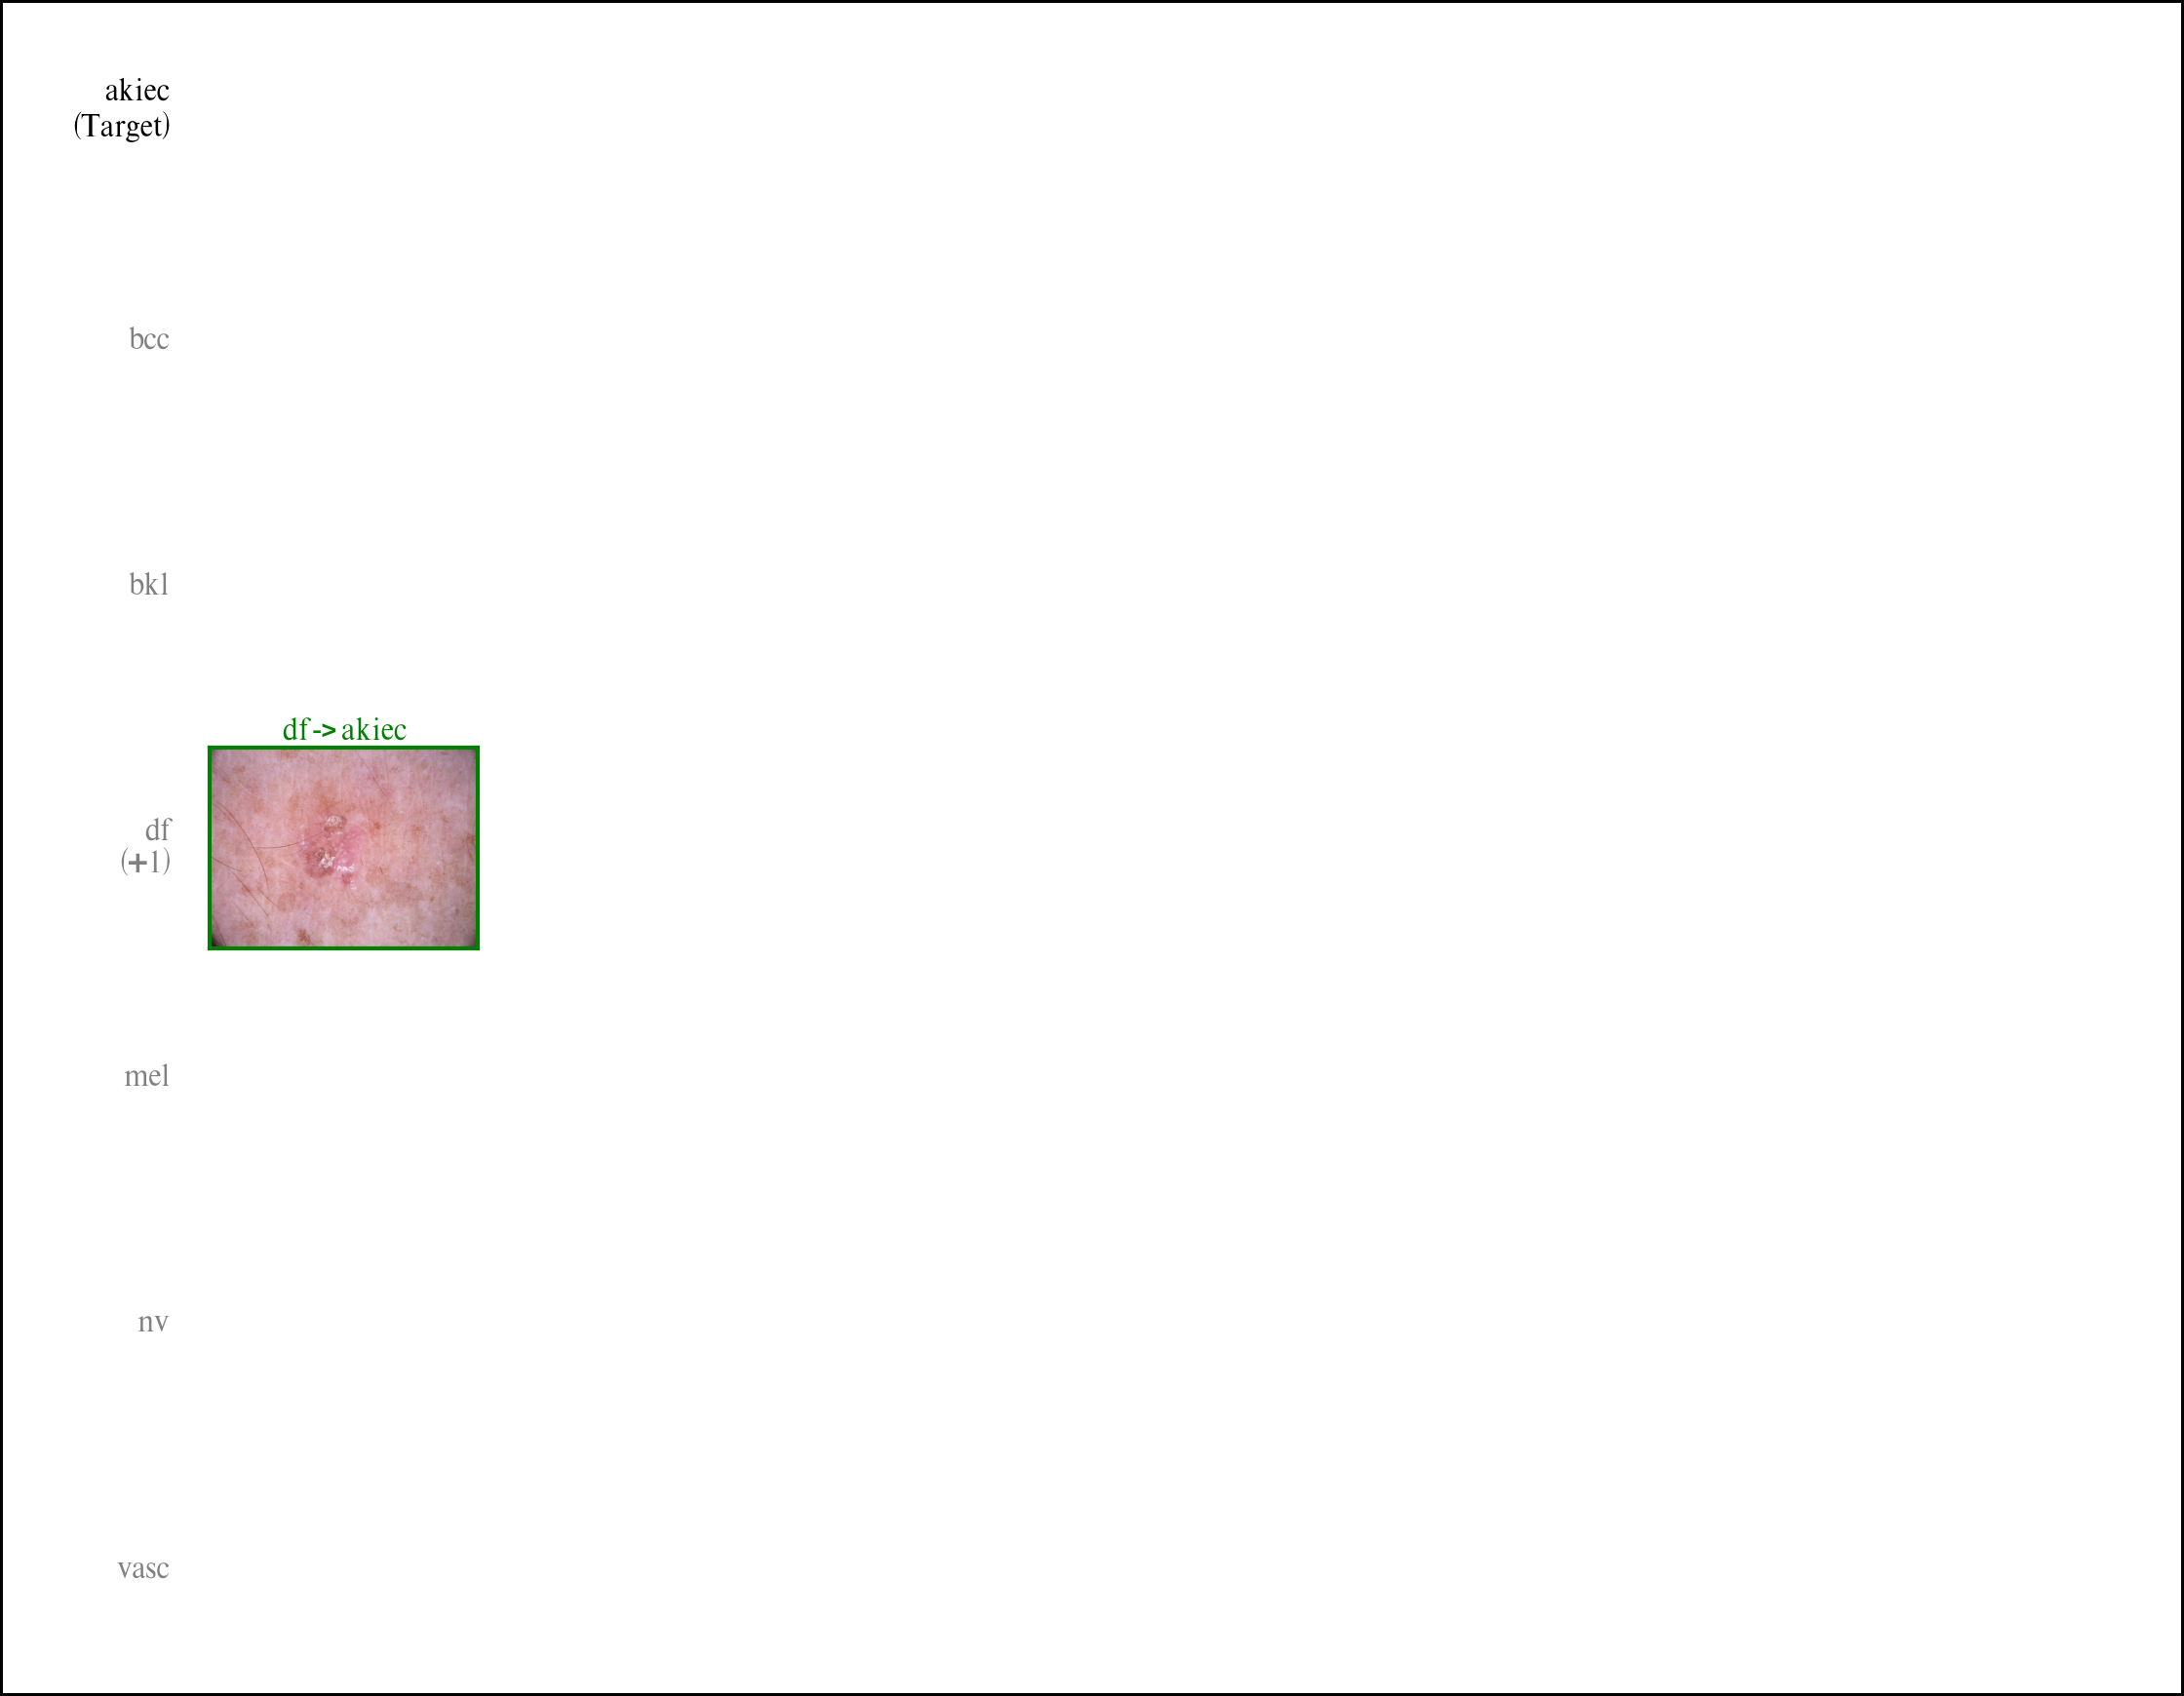

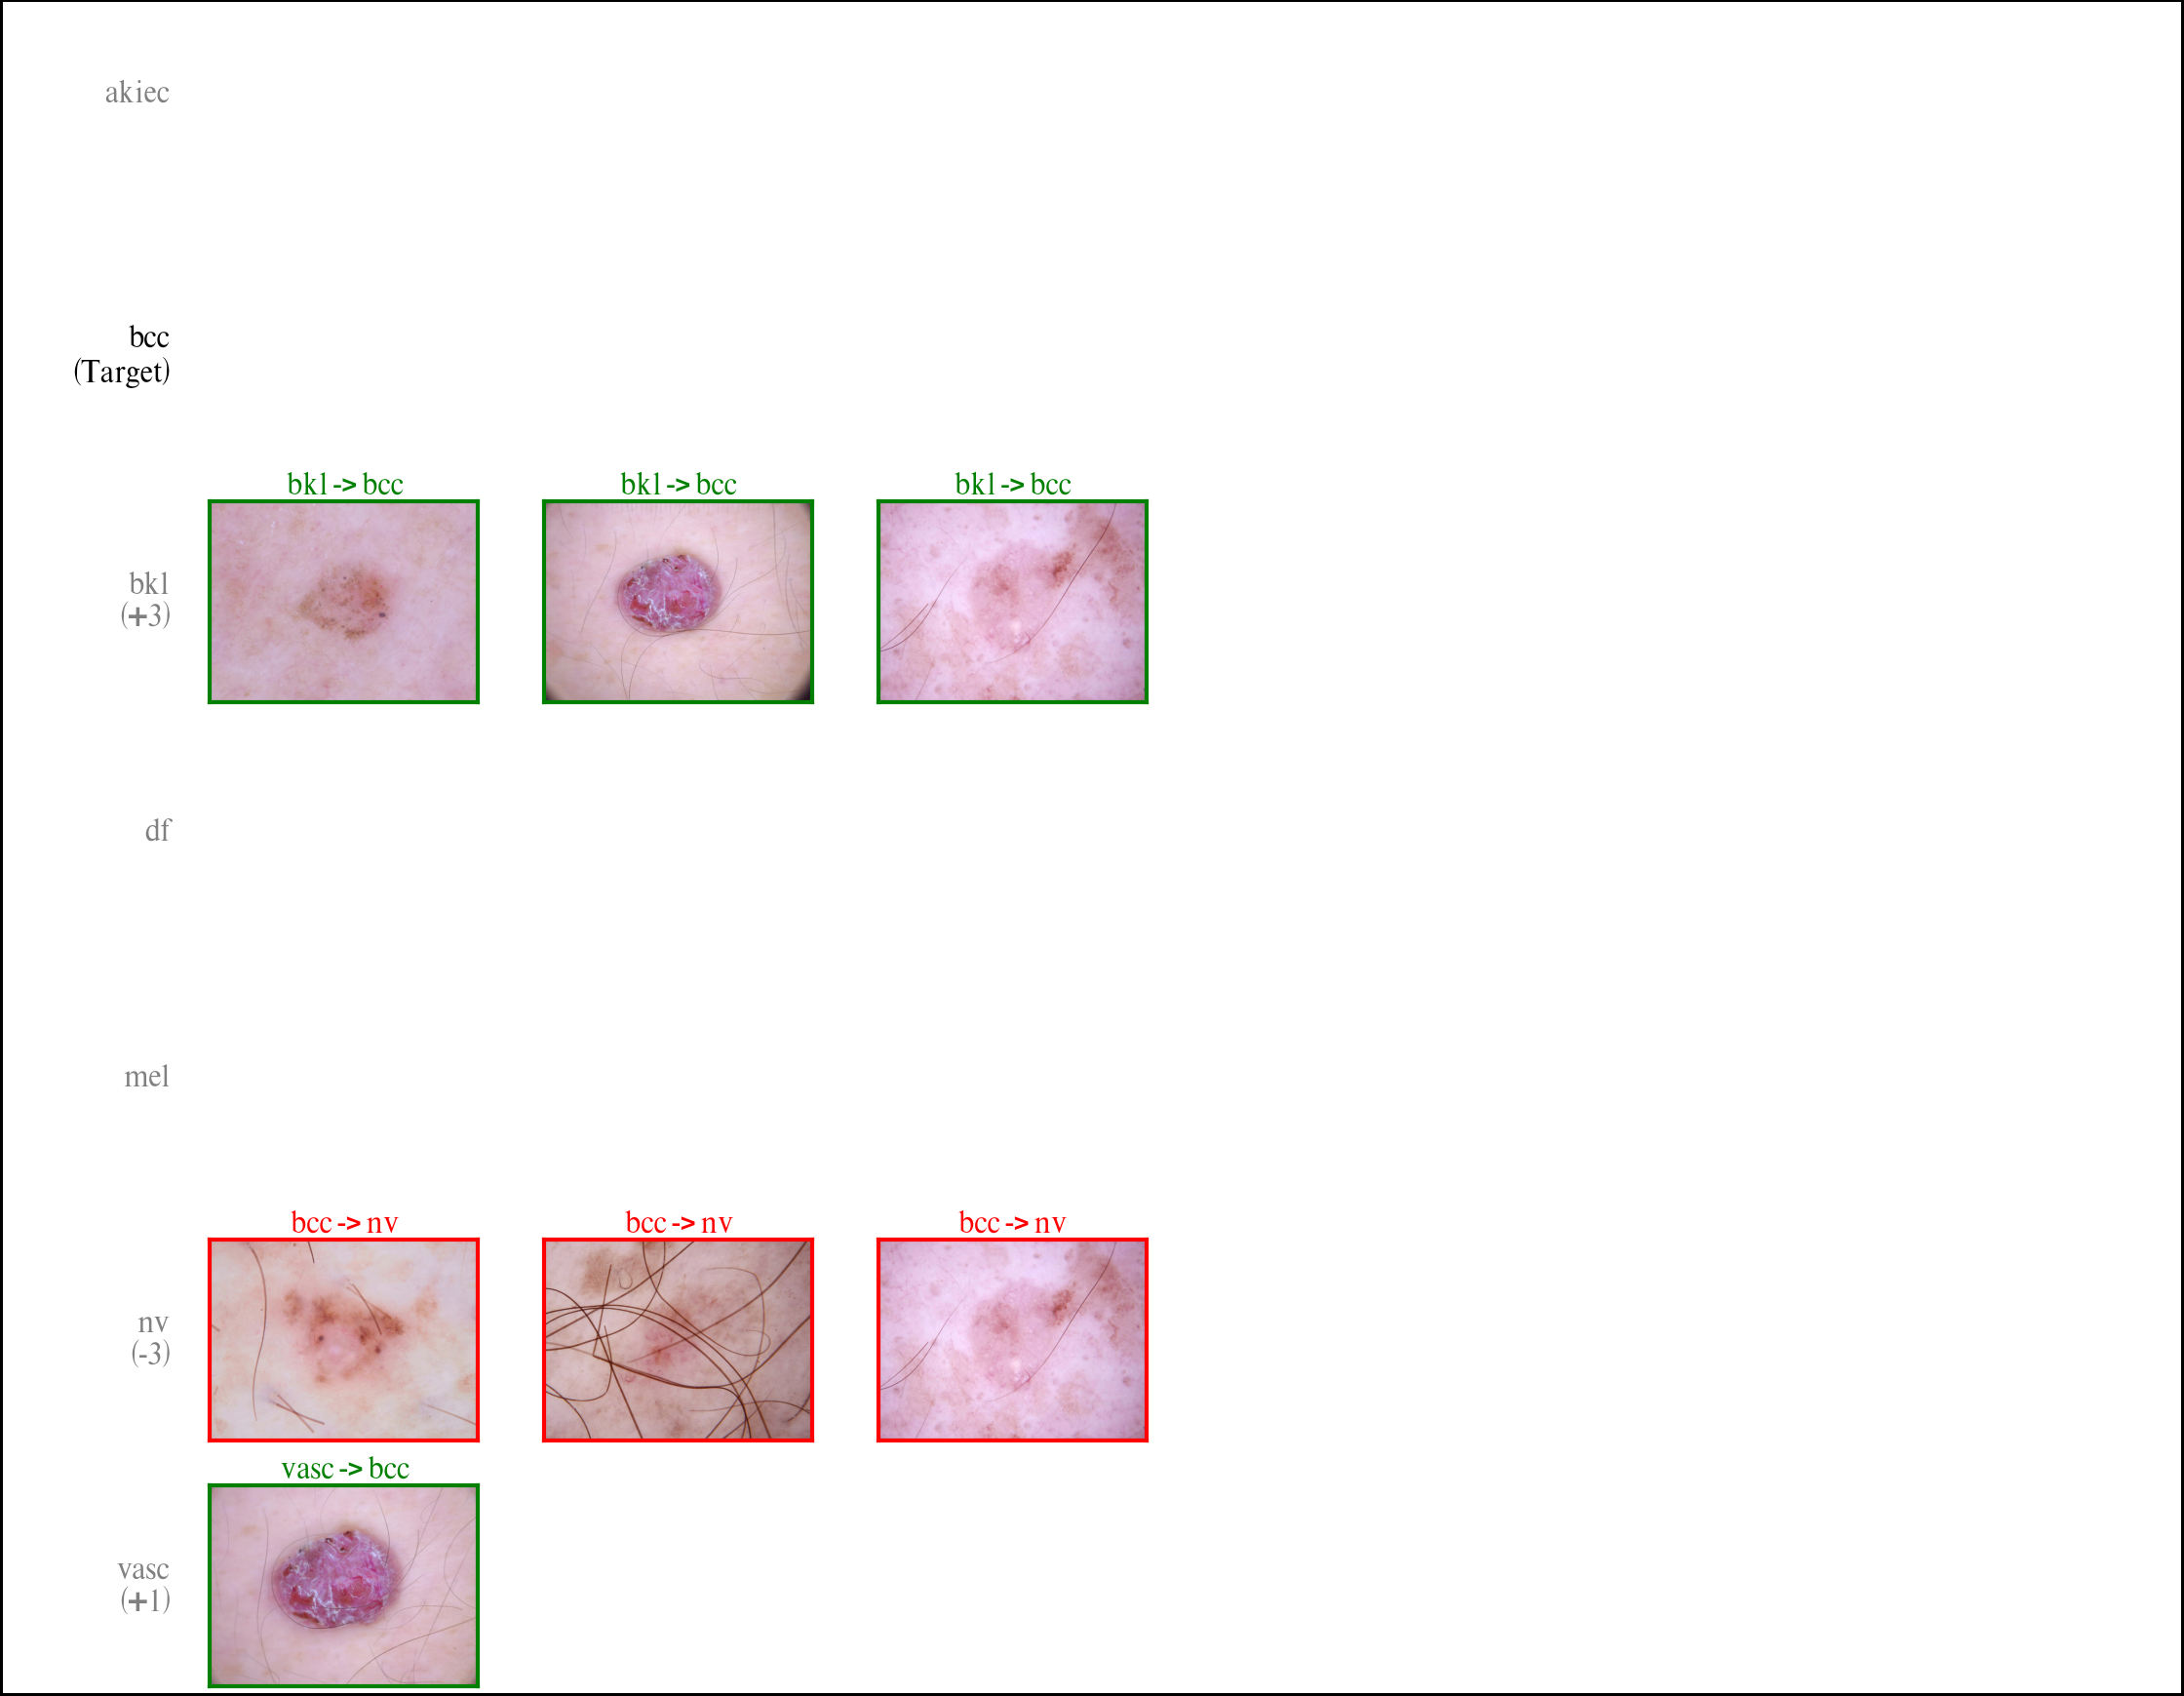

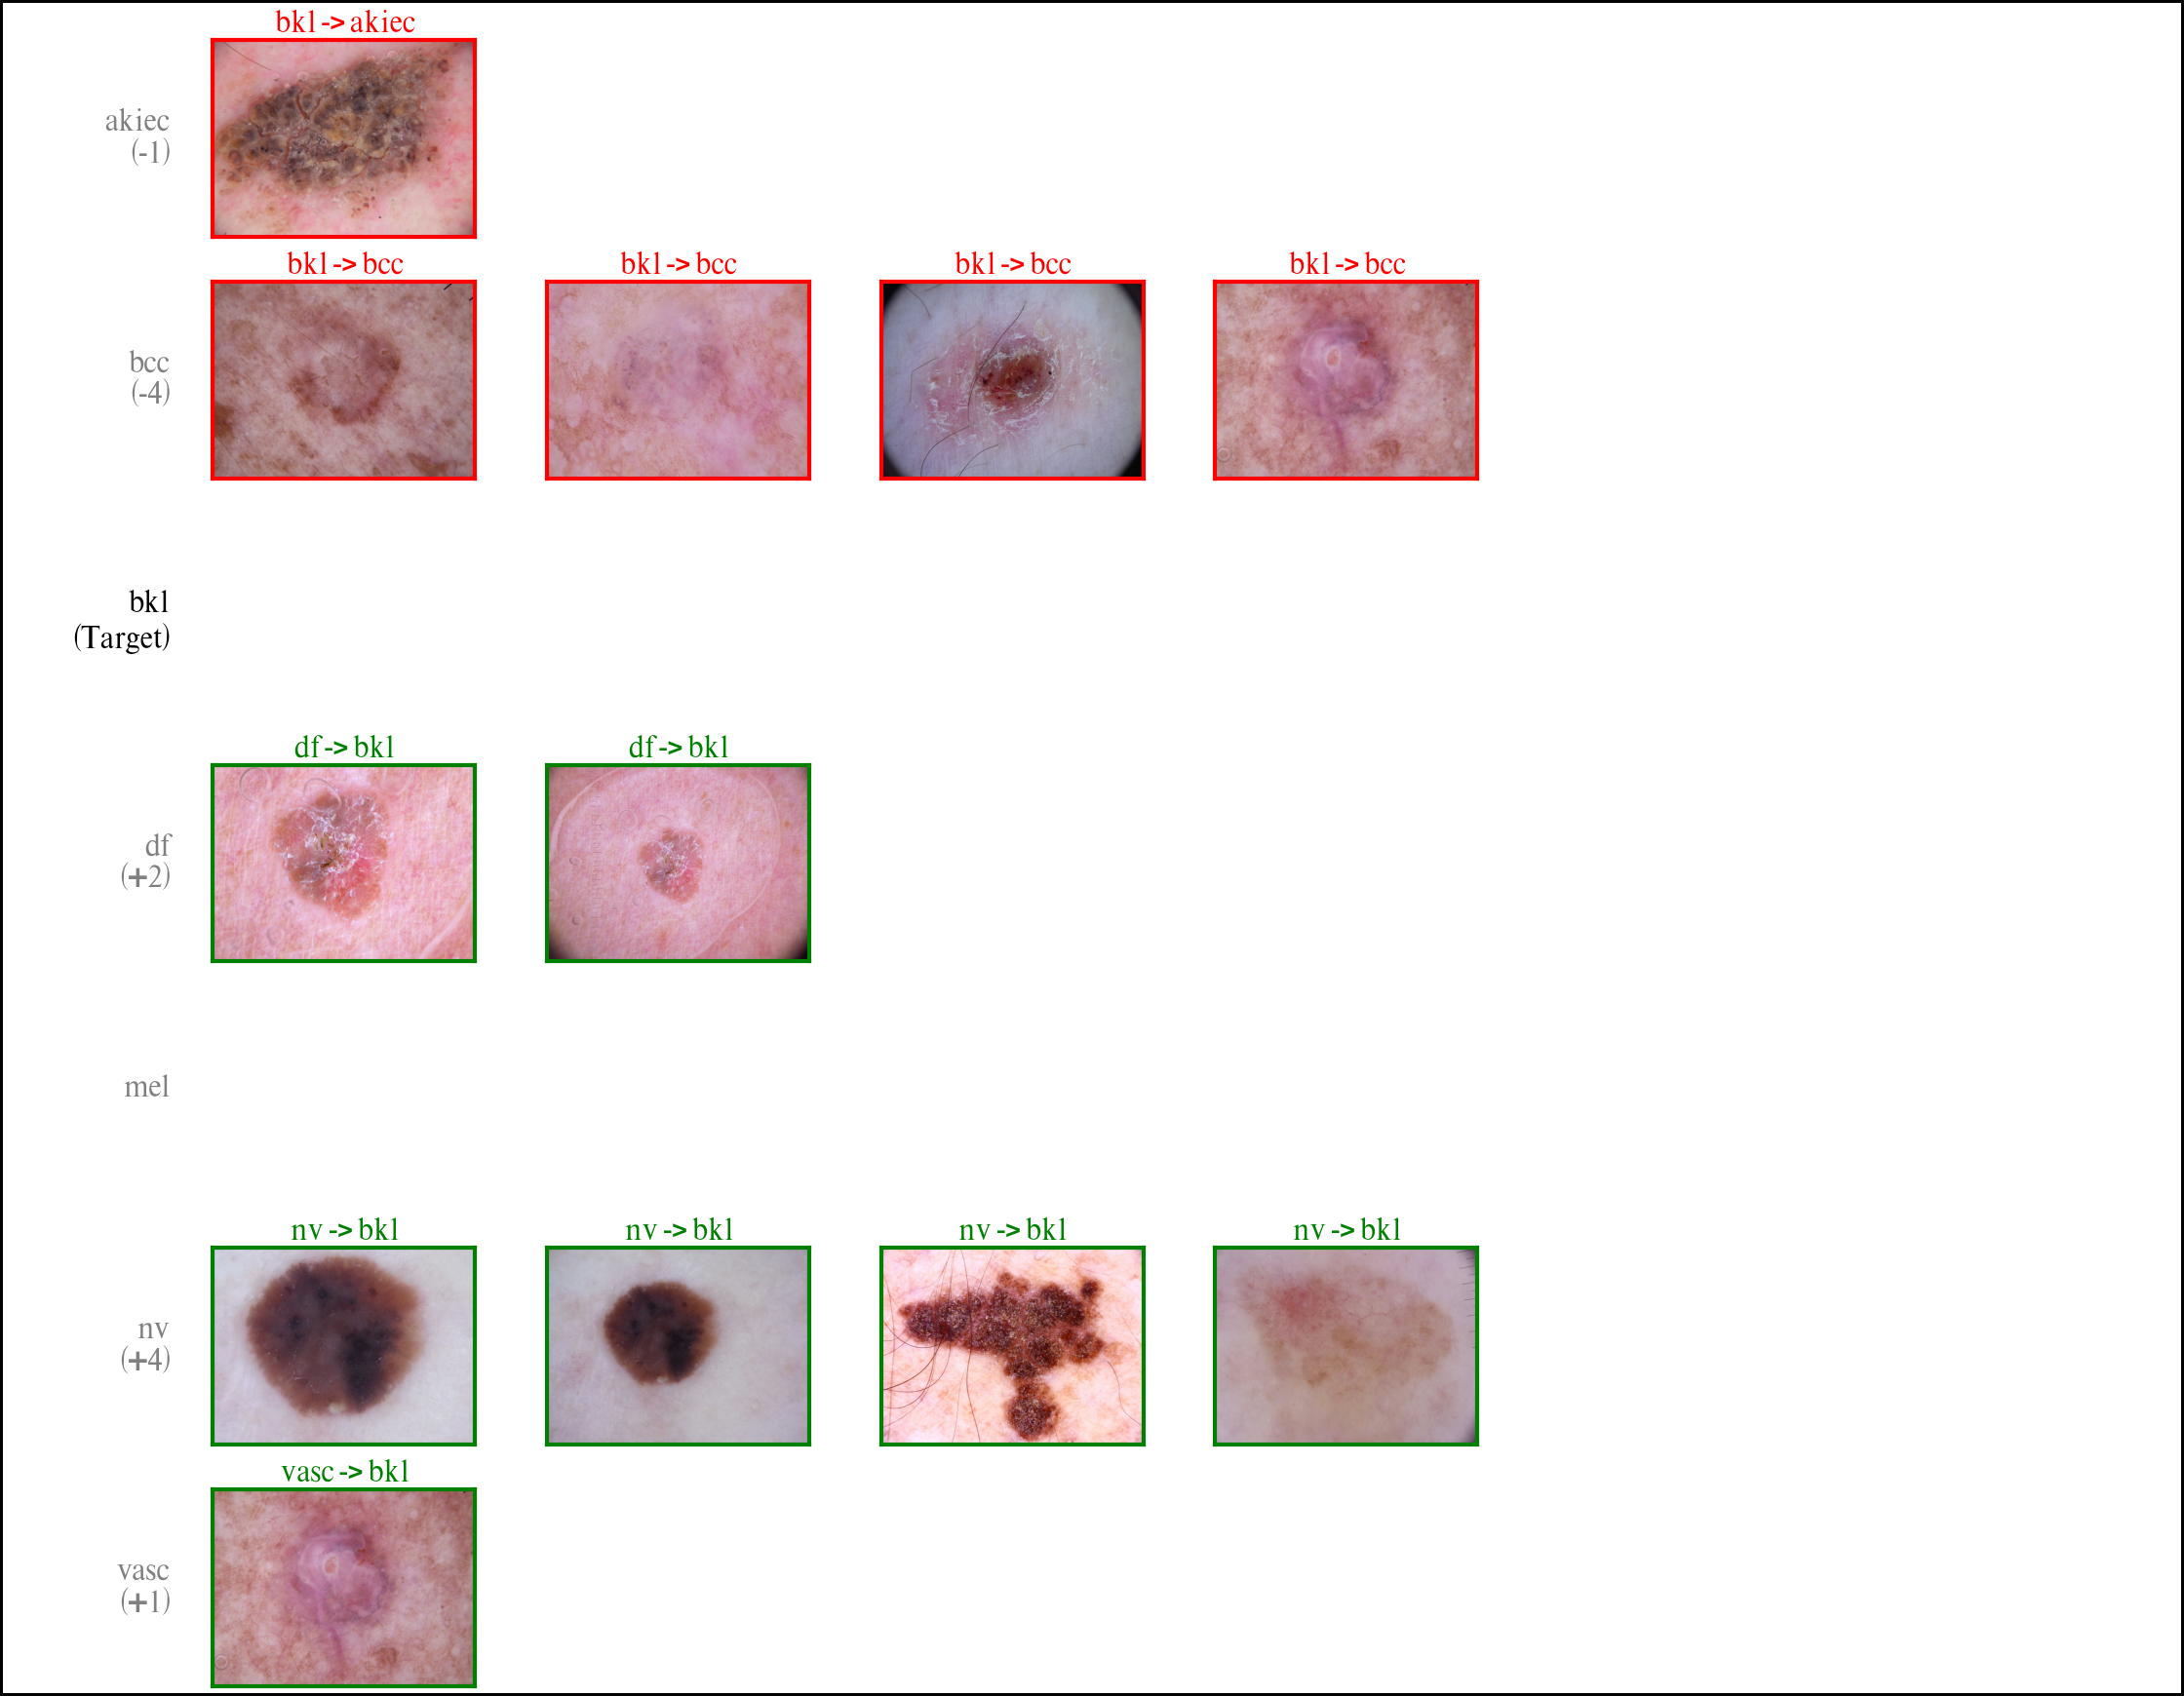

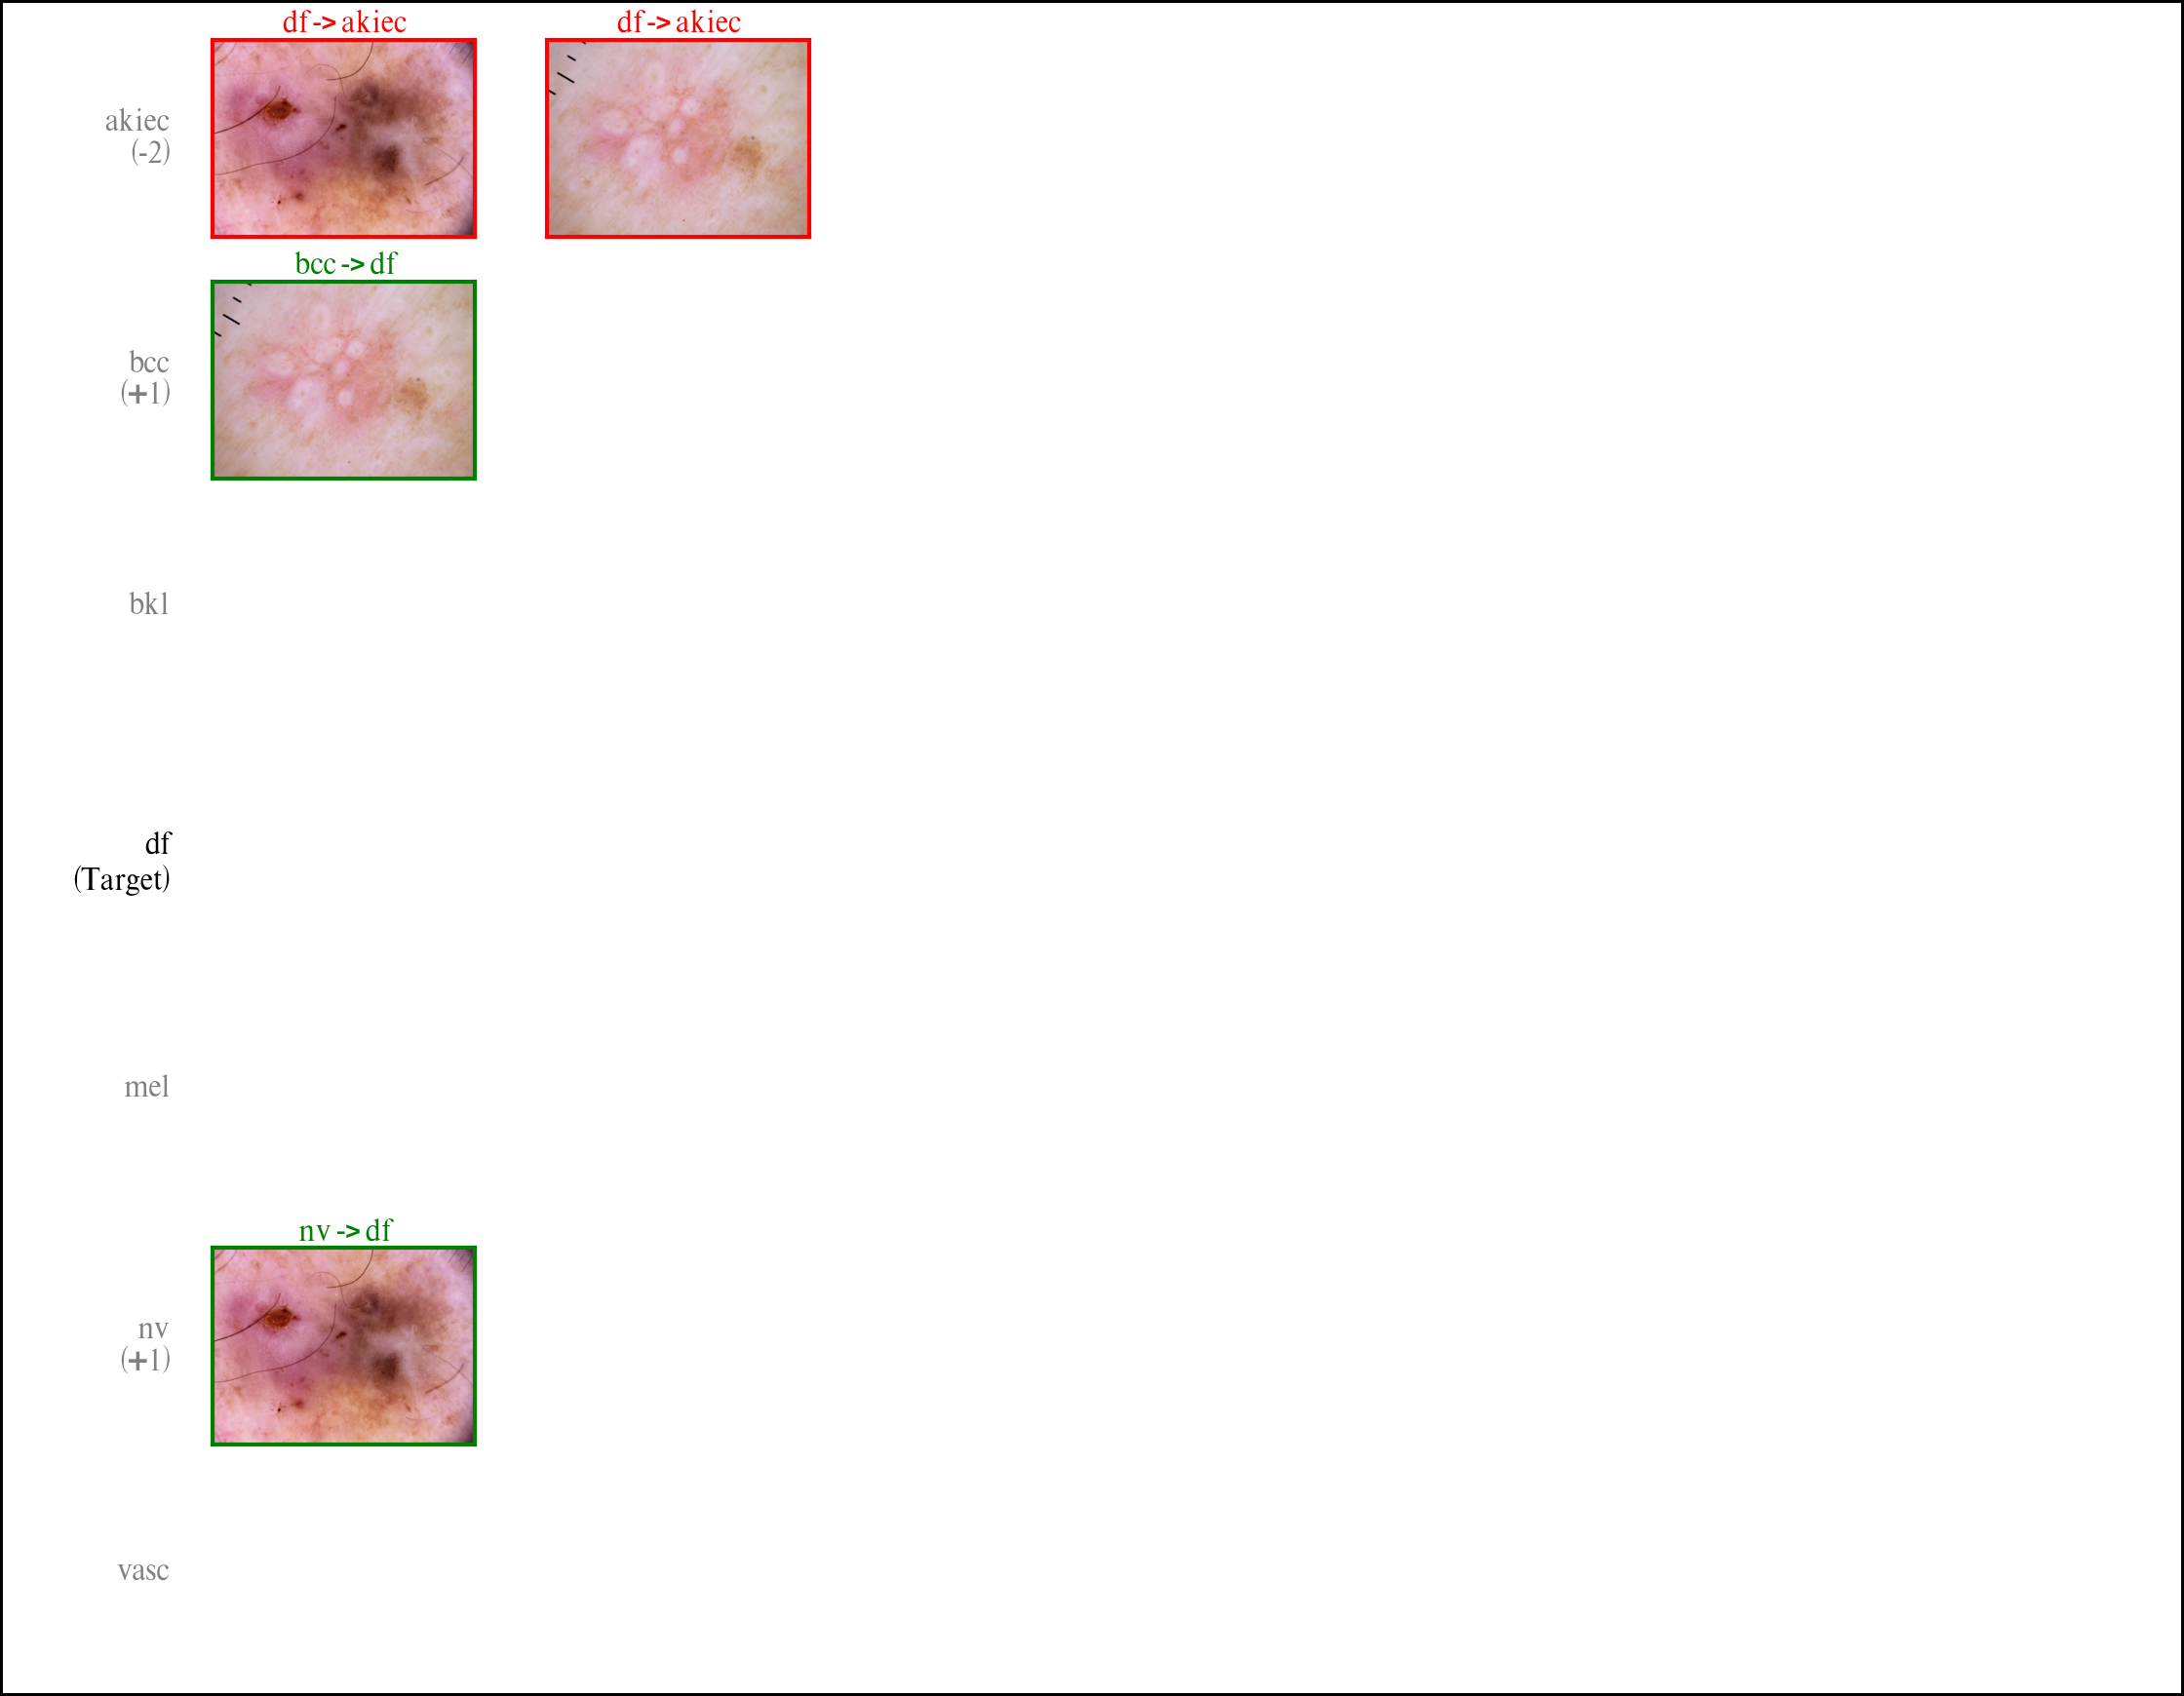

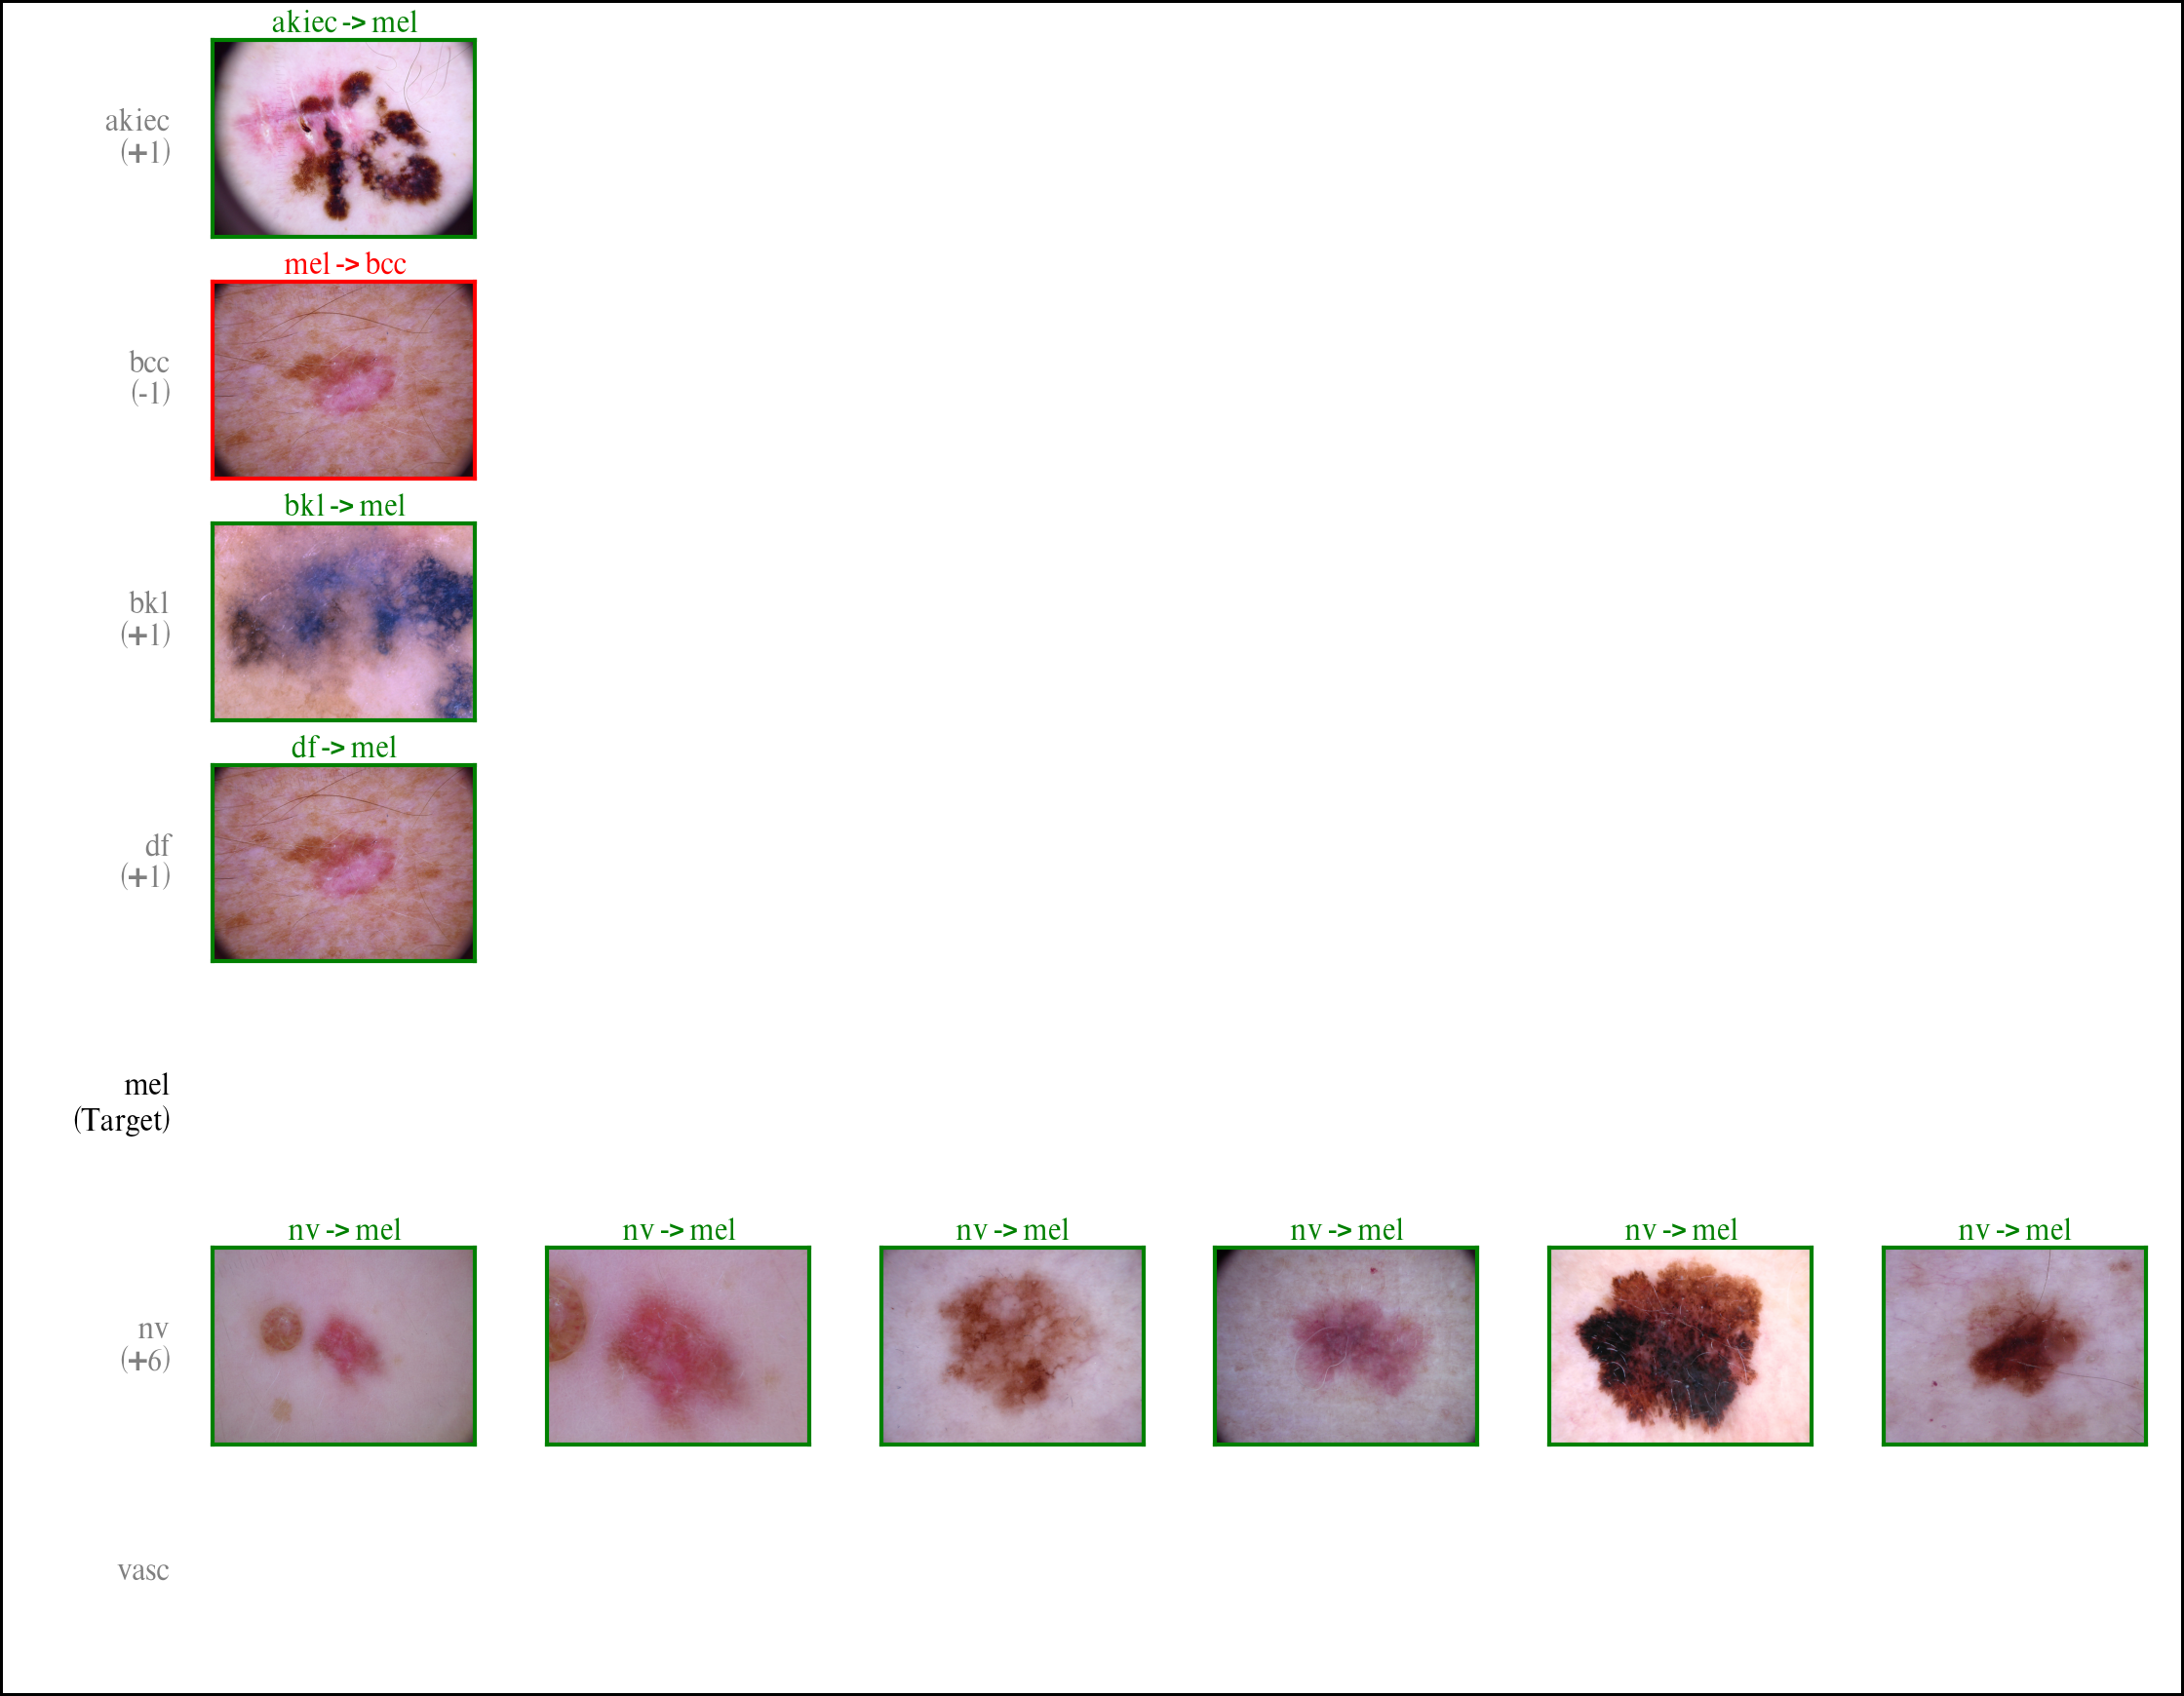

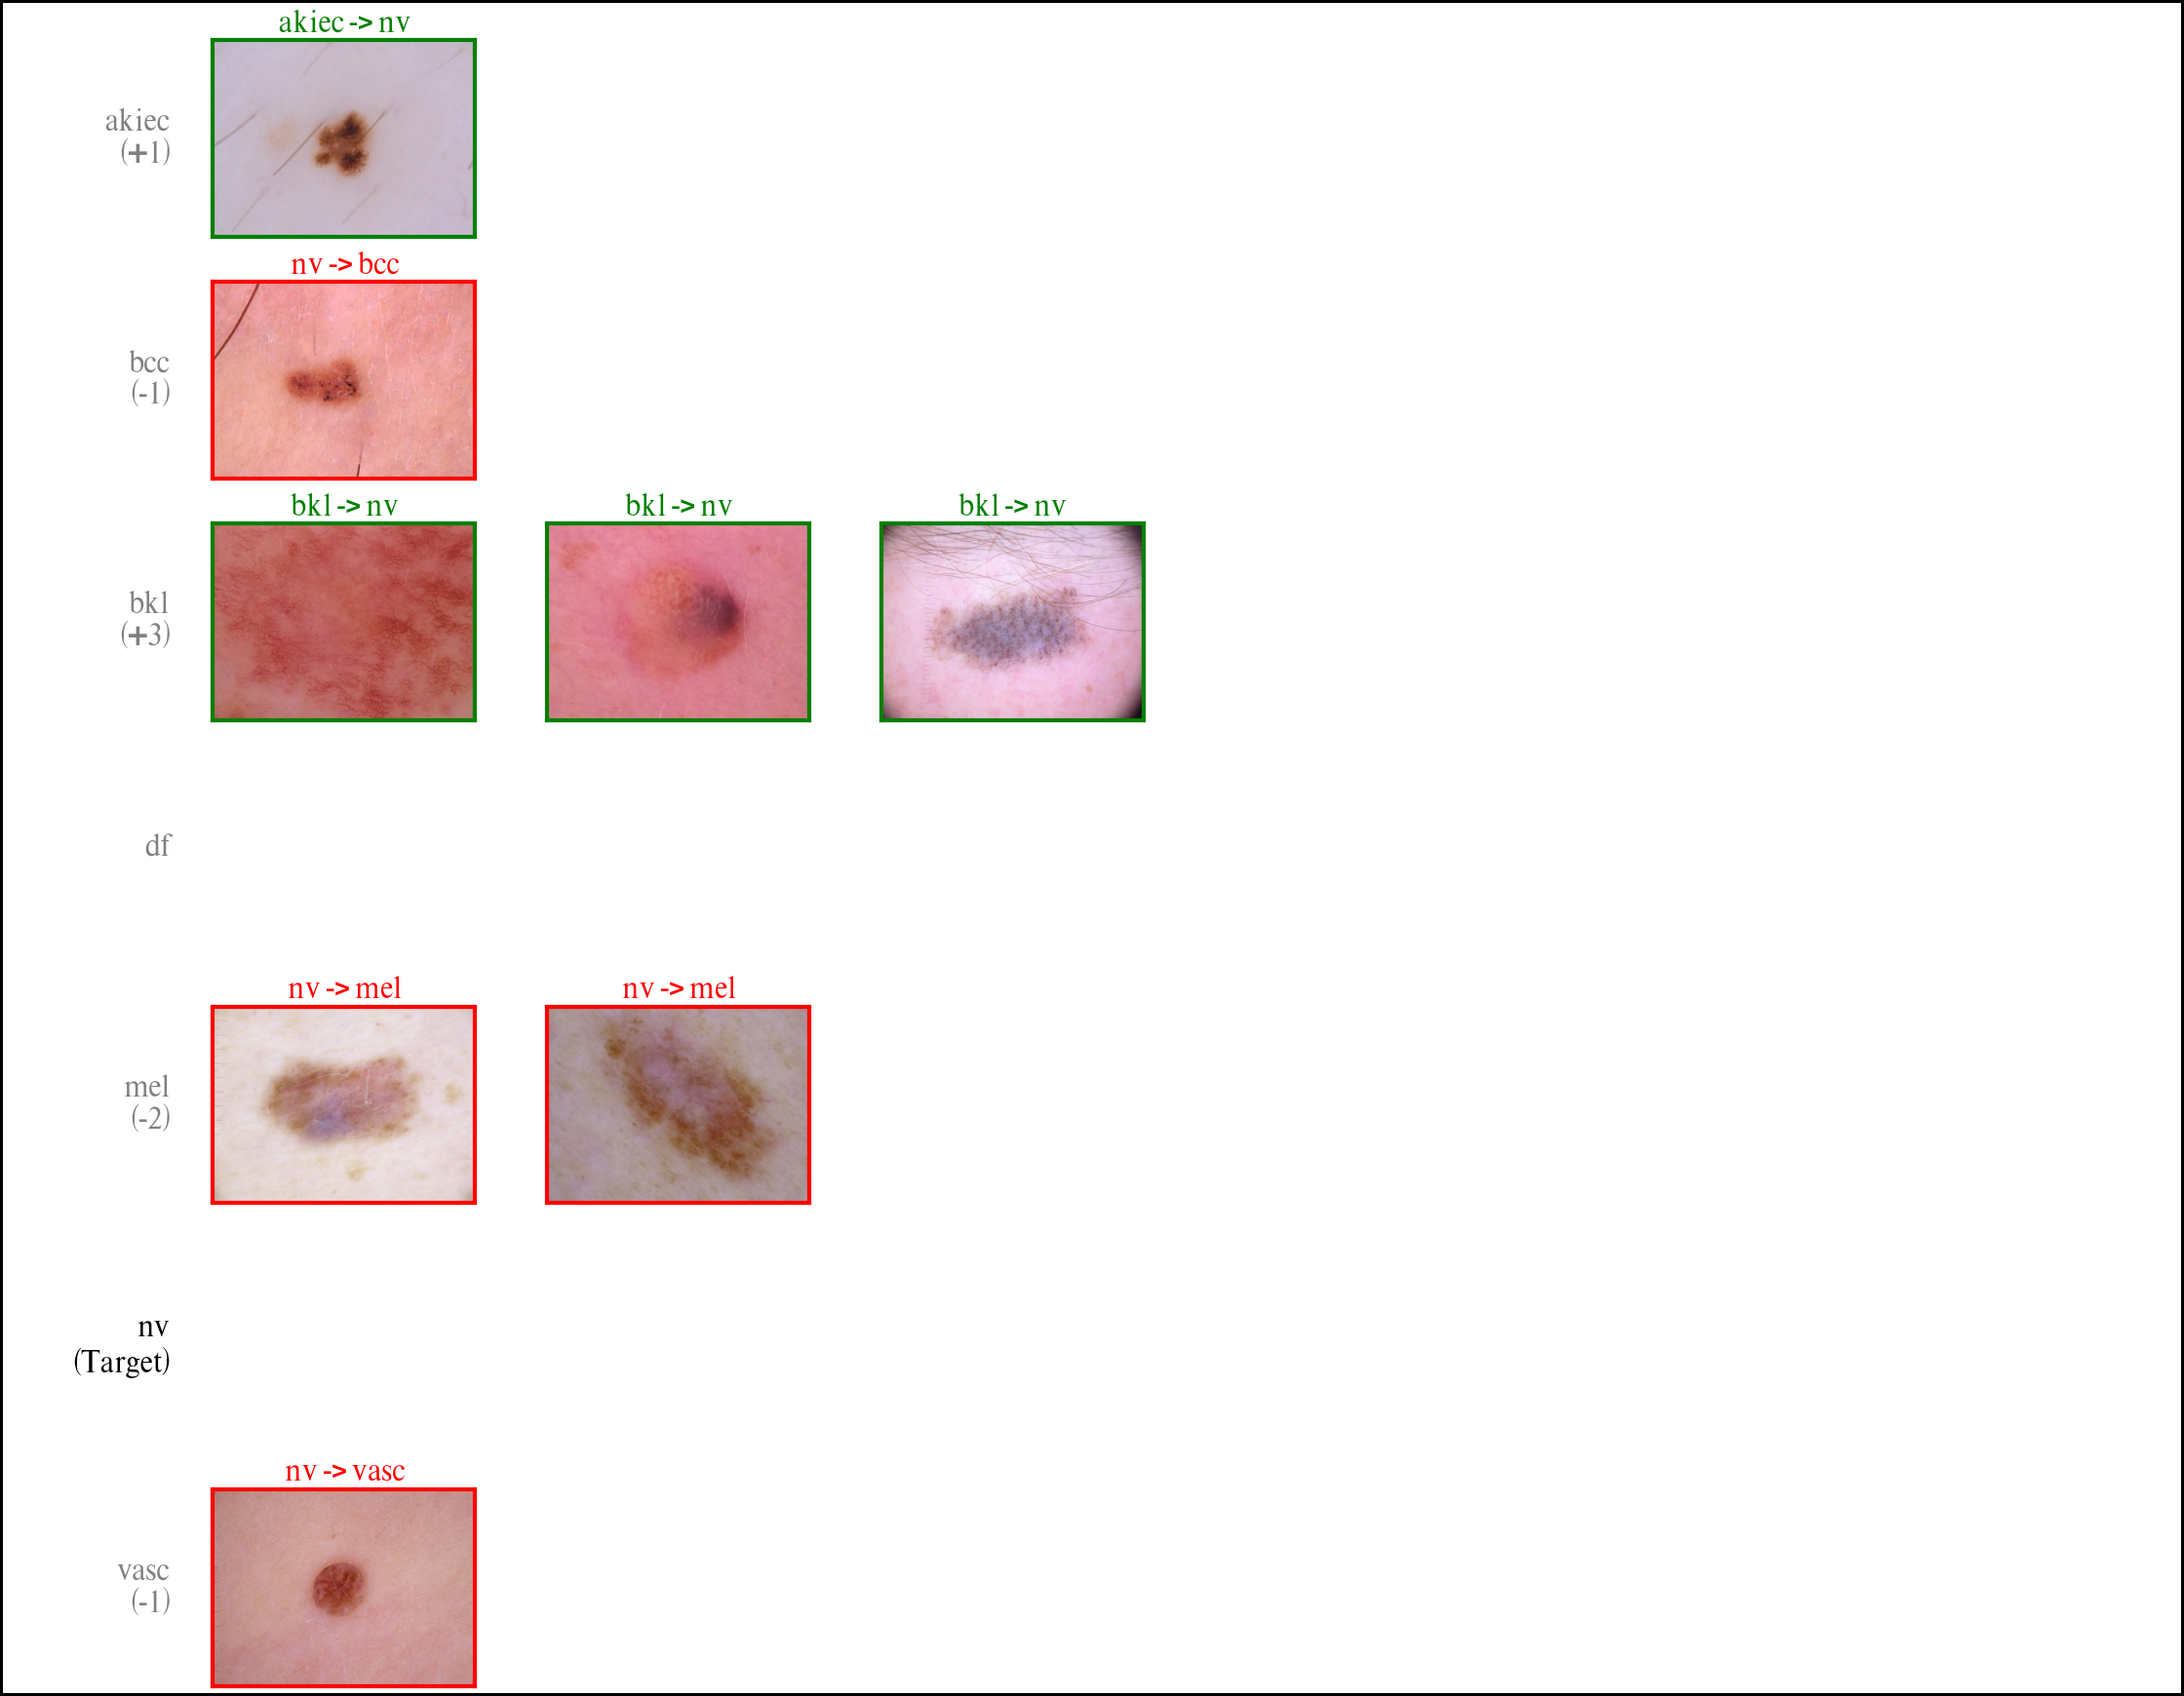

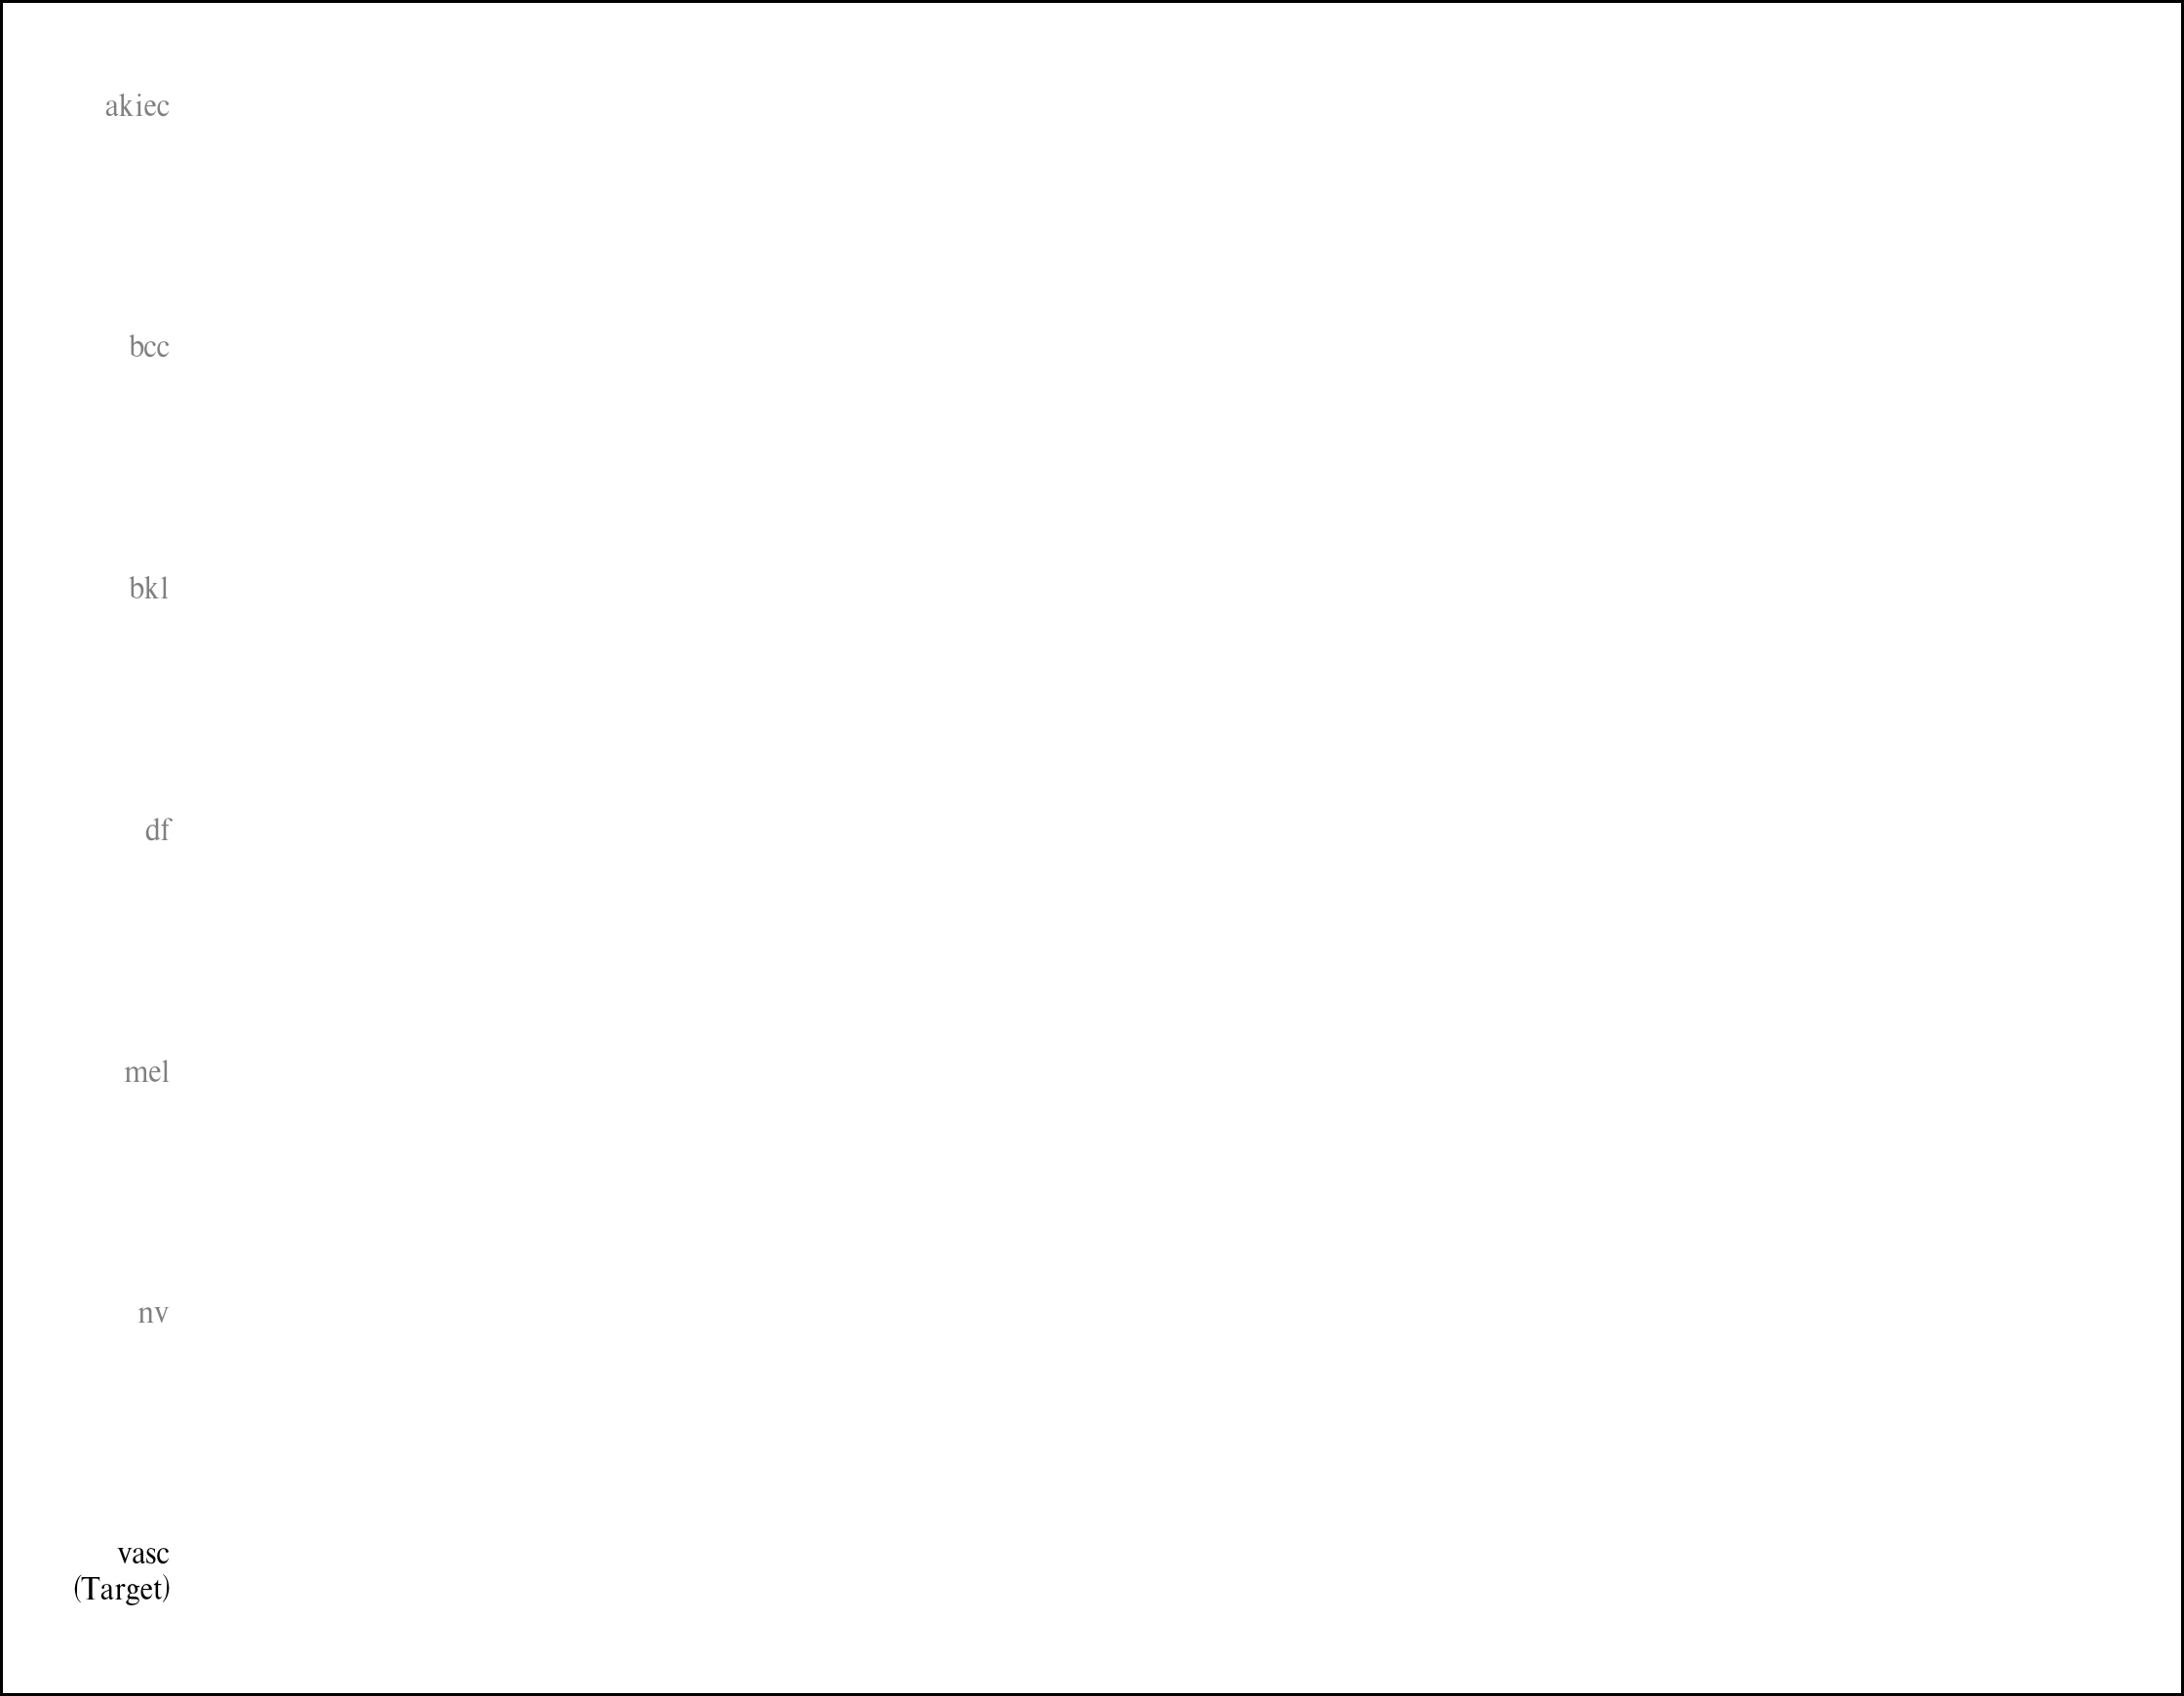

In [26]:
plot_transition_images(transition_data, class_names, max_cols, DIFF_CONF_PATH)

In [27]:
df_transition = to_dataframe(transition_data)
df_transition.to_csv(f"{DIFF_CONF_PATH}/transition_data.csv", index=False)

## **Section 4: Confusion Matrix for Presentation**

In [28]:
MODEL_CODE_NAME = "EfficientNetV2B0"
BASELINE_TYPE_CODE_NAME = "Only Pretrained"
MLP_TYPE_CODE_NAME = "Multimodal with MLP"

In [29]:
baseline_new_conf_path = f'{DIFF_CONF_PATH}/baseline.png'
mlp_new_conf_path = f'{DIFF_CONF_PATH}/mlp.png'

baseline_title = f'{MODEL_CODE_NAME} {BASELINE_TYPE_CODE_NAME}'
mlp_title = f'{MODEL_CODE_NAME} {MLP_TYPE_CODE_NAME}'

In [30]:
def plot_confusion_matrix(cm, classes, title=None, cmap=plt.cm.Blues, save_path=None, fontsize=12):
    correct_predictions = np.trace(cm)
    total_samples = np.sum(cm)
    accuracy = correct_predictions / total_samples
    misclassification_rate = 1 - accuracy

    pic_title = f"{title}\nConfusion Matrix (normalized)" if title else "Confusion Matrix (normalized)"

    plt.figure(figsize=(10, 7))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm_normalized, interpolation="none", cmap=cmap, vmin=0, vmax=1)

    plt.title(pic_title, fontsize=fontsize, ha="center", weight='bold')
    plt.colorbar(ticks=np.linspace(0, 2, 11))

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=fontsize)
    plt.yticks(tick_marks, classes, fontsize=fontsize)

    thresh = 0.5

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        count = cm[i, j]
        rate = cm_normalized[i, j]
        text_label = f"{rate:.2f}\n({int(count)})"

        plt.text(j, i, text_label,
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=fontsize - 1,
                 color="white" if rate > thresh else "black",
                 weight='bold' if rate > thresh else 'normal')

    plt.ylabel('True label', fontsize=fontsize)
    metrics_text = (f"\nAccuracy: {accuracy:.4f}  |  Misclass: {misclassification_rate:.4f}")
    plt.xlabel(f"Predicted label{metrics_text}", fontsize=fontsize)
    plt.tight_layout()

    if save_path:
        plt.savefig(f"{save_path}", format="png", dpi=300, bbox_inches="tight")

    plt.show()

### **Baseline**

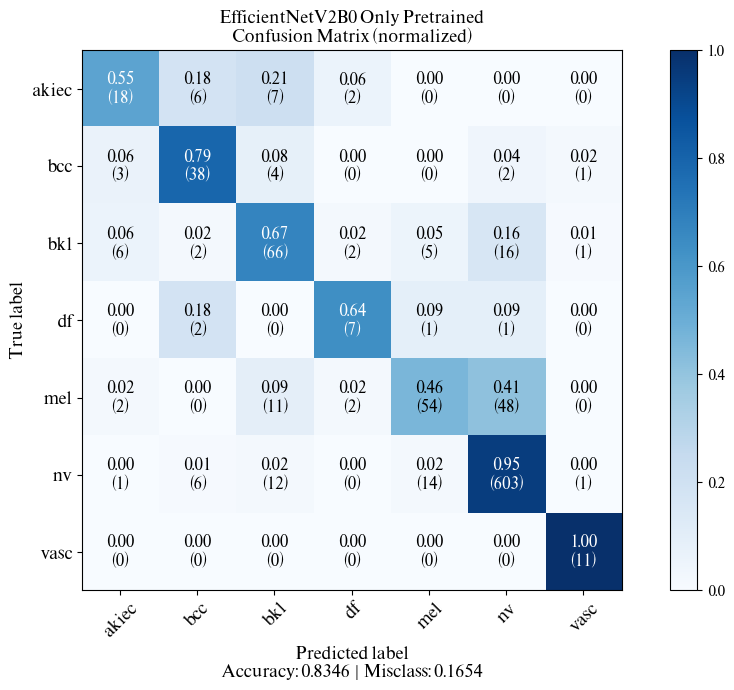

In [31]:
plot_confusion_matrix(cm=cm_baseline, classes=class_names, title=baseline_title, save_path=baseline_new_conf_path)

### **Multimodal**

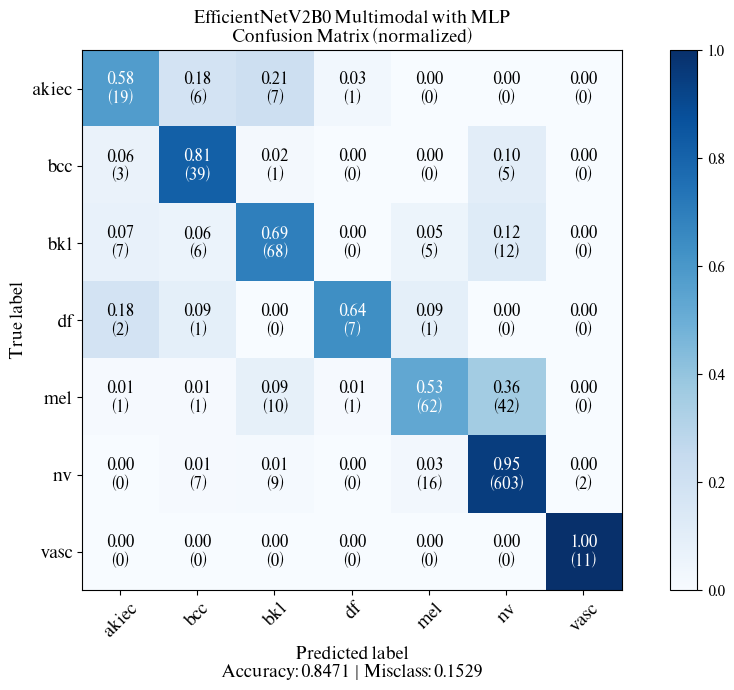

In [32]:
plot_confusion_matrix(cm=cm_mlp, classes=class_names, title=mlp_title, save_path=mlp_new_conf_path)